# COMP90051 Project: Multi-Stock S&P 500 Direction Prediction with Systematic Feature Selection

This section prepares the Python environment for the project. It performs two key tasks:

1.  **Installs Libraries:** It silently installs all the necessary external libraries, such as `pandas` for data handling, `yfinance` for downloading stock data, and `scikit-learn` for machine learning.
2.  **Imports Modules:** It imports all the required functions and modules that will be used throughout the notebook.

## 0: Research Question Recap

**Research Question:** How does Random Forest permutation importance-based feature selection from multi-scale temporal features impact the performance of machine learning models for next-day directional prediction across S&P 500 constituent stocks?

This question decomposes into three sub-questions:
1. Do permutation-selected features (20 features) outperform both minimal baseline (5 raw OHLCV features) and high-dimensional unselected features (128 engineered features)?
2. How does feature selection impact model performance across different model complexities (linear, ensemble, deep learning)?
3. Does feature selection reduce overfitting while maintaining or improving generalization performance?

## 1: Environment Setup

In [ ]:
!pip3 install -r requirements.txt

In [ ]:
# ============================================================================
# PART 1: ENVIRONMENT SETUP
# ============================================================================

# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from typing import Dict, Tuple

warnings.filterwarnings('ignore')

# Data collection
import yfinance as yf


# Machine Learning (using sklearn implementations but custom CV)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Set random seeds for reproducibility
np.random.seed(90051)
tf.random.set_seed(90051)

print("Environment setup complete!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"TensorFlow version: {tf.__version__}")

Environment setup complete!
NumPy version: 2.0.2
Pandas version: 2.3.3
TensorFlow version: 2.20.0


## 2: Data Acquisition and Preprocessing

This section handles the crucial first steps of the project: getting the data and ensuring it's clean and reliable. It covers:

1.  **Data Download:** It fetches historical price data for 15 selected stocks from major sectors of the S&P 500. This provides a diverse and representative dataset.
2.  **Initial Cleaning:** It performs essential cleaning tasks, such as handling missing values and correcting any obvious errors in the price data (e.g., a day's low being higher than its high).
3.  **Basic Calculations:** It computes daily returns, which are a foundational element for many of the features we will create later.


### 2.1 Data Acquisition

In [3]:
def download_multi_stock_data(
    stock_dict: Dict[str, str],
    start_date: str = '2018-01-01',
    end_date: str = None,
    min_valid_days: int = 1000
) -> Tuple[pd.DataFrame, list]:
    """
    Downloads and combines historical stock data for multiple tickers.

    This function iterates through a dictionary of stock tickers, downloads
    historical price data using the yfinance library, and combines them into a
    single pandas DataFrame. It includes error handling for failed downloads
    and filters out stocks with insufficient data.

    Args:
        stock_dict: A dictionary mapping tickers to their respective sectors
                    (e.g., {'AAPL': 'Technology'}).
        start_date: The start date for the data download in 'YYYY-MM-DD' format.
        end_date: The end date for the data download. If None, downloads up to the
                  most recent available data.
        min_valid_days: The minimum number of trading days a stock must have to be
                        included in the final dataset.

    Returns:
        A tuple containing:
        - A pandas DataFrame with the combined, sorted data for all successful tickers.
        - A list of tickers for which the data download failed.
    """
    print(f"\nDownloading data from {start_date} to {end_date or 'today'}...")

    all_data = []
    failed_tickers = []

    for ticker, sector in stock_dict.items():
        try:
            # Download data
            df = yf.download(
                ticker,
                start=start_date,
                end=end_date,
                auto_adjust=True,
                progress=False
            )

            # Verify data quality
            if len(df) < min_valid_days:
                print(f"  ⚠ {ticker}: Only {len(df)} days (< {min_valid_days}), skipping")
                failed_tickers.append(ticker)
                continue

            # Simplify column names if needed
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]

            # Add metadata
            df['ticker'] = ticker
            df['sector'] = sector

            all_data.append(df)
            print(f"  ✓ {ticker} ({sector}): {len(df)} days")

        except Exception as e:
            print(f"  ✗ {ticker}: Failed - {str(e)}")
            failed_tickers.append(ticker)

    if not all_data:
        raise ValueError("No data downloaded successfully!")

    # Combine all data
    combined = pd.concat(all_data, axis=0)
    combined = combined.sort_index()

    print(f"\n✓ Download complete!")
    print(f"  Successful: {len(all_data)} stocks")
    print(f"  Failed: {len(failed_tickers)} stocks")
    print(f"  Total records: {len(combined):,}")
    print(f"  Date range: {combined.index.min().date()} to {combined.index.max().date()}")

    return combined, failed_tickers


In [4]:
STOCK_UNIVERSE = {
    # Technology (4 stocks - largest tech companies)
    'AAPL': 'Technology',      # Apple - largest market cap
    'MSFT': 'Technology',      # Microsoft
    'GOOGL': 'Technology',     # Alphabet
    'NVDA': 'Technology',      # NVIDIA - AI leader

    # Healthcare (3 stocks - diverse healthcare exposure)
    'UNH': 'Healthcare',       # UnitedHealth - insurance
    'JNJ': 'Healthcare',       # Johnson & Johnson - pharma/consumer
    'LLY': 'Healthcare',       # Eli Lilly - biotech

    # Financial (3 stocks - major financial institutions)
    'JPM': 'Financial',        # JPMorgan Chase - largest US bank
    'V': 'Financial',          # Visa - payments
    'MA': 'Financial',         # Mastercard - payments

    # Consumer (2 stocks - e-commerce and retail)
    'AMZN': 'Consumer',        # Amazon - e-commerce leader
    'WMT': 'Consumer',         # Walmart - retail leader

    # Energy (2 stocks - oil majors)
    'XOM': 'Energy',           # ExxonMobil - largest US oil
    'CVX': 'Energy',           # Chevron

    # Industrial (1 stock - diversified industrial)
    'CAT': 'Industrial',       # Caterpillar - industrial bellwether
}


print(f"\nStock Universe Definition:")
print(f"  Total stocks: {len(STOCK_UNIVERSE)}")
print(f"  Sectors: {len(set(STOCK_UNIVERSE.values()))}")
print("\nSector Distribution:")
sector_counts = pd.Series(STOCK_UNIVERSE.values()).value_counts()
for sector, count in sector_counts.items():
    print(f"  {sector}: {count} stocks")



Stock Universe Definition:
  Total stocks: 15
  Sectors: 6

Sector Distribution:
  Technology: 4 stocks
  Healthcare: 3 stocks
  Financial: 3 stocks
  Consumer: 2 stocks
  Energy: 2 stocks
  Industrial: 1 stocks




**Purpose**: Define a small, reliable set of S&P 500 tickers for reproducible data pulls and fast iteration. The goal is to balance data quality (liquidity, continuity) with runtime constraints for feature engineering + nested CV.

**Selection Criteria**
- Liquidity first: large-cap names that download cleanly via yfinance and minimize missing/corporate action edge cases.
- Sector coverage: include Tech, Healthcare, Financials, Consumer, Energy, Industrials to reduce sector bias.
- Time window: 2022-01-01 → today (auto_adjust=True for split/dividend consistency).
- Warm-up friendly: supports long lookbacks (e.g., 200d MAs) without collapsing per–stock sample counts.
- Min length: filter out tickers with <500 valid trading days (min_valid_days) to maintain signal integrity.
- Runtime: ~15 tickers keeps 9 feature sets × nested CV tractable on a single machine.

**Notes**
- Expect ~14k raw rows pre-clean; >10k usable after cleaning and feature warm-ups.
- Large, liquid names help reduce microstructure noise for next‑day direction labels.

In [5]:
# Set up parameters for data acquisition
START_DATE = '2022-01-01' # Set to be 2022-01-01 which represent post-covid period
MIN_VALID_DAYS = 200 # Set to be 500 which is the minimum number of trading days for a stock to be included so it can be used for feature engineering
# Download data
raw_data, failed_stocks = download_multi_stock_data(
    STOCK_UNIVERSE,
    start_date=START_DATE,
    end_date=None,
    min_valid_days=MIN_VALID_DAYS
)

# Update stock universe (remove failed stocks that could not be downloaded)
STOCK_UNIVERSE = {k: v for k, v in STOCK_UNIVERSE.items() if k not in failed_stocks}

print(f"\n✓ Final dataset: {len(STOCK_UNIVERSE)} stocks, {len(raw_data):,} records")



  ✓ AAPL (Technology): 950 days
  ✓ MSFT (Technology): 950 days
  ✓ GOOGL (Technology): 950 days
  ✓ NVDA (Technology): 950 days
  ✓ UNH (Healthcare): 950 days
  ✓ JNJ (Healthcare): 950 days
  ✓ LLY (Healthcare): 950 days
  ✓ JPM (Financial): 950 days
  ✓ V (Financial): 950 days
  ✓ MA (Financial): 950 days
  ✓ AMZN (Consumer): 950 days
  ✓ WMT (Consumer): 950 days
  ✓ XOM (Energy): 950 days
  ✓ CVX (Energy): 950 days
  ✓ CAT (Industrial): 950 days

✓ Download complete!
  Successful: 15 stocks
  Failed: 0 stocks
  Total records: 14,250
  Date range: 2022-01-03 to 2025-10-15

✓ Final dataset: 15 stocks, 14,250 records


### 2.2 Exploratory Data Analysis (EDA)


SECTION 2.2: EXPLORATORY DATA ANALYSIS

--- Analyzing Stock Price Trends ---
✓ Saved: stock_price_trends.png


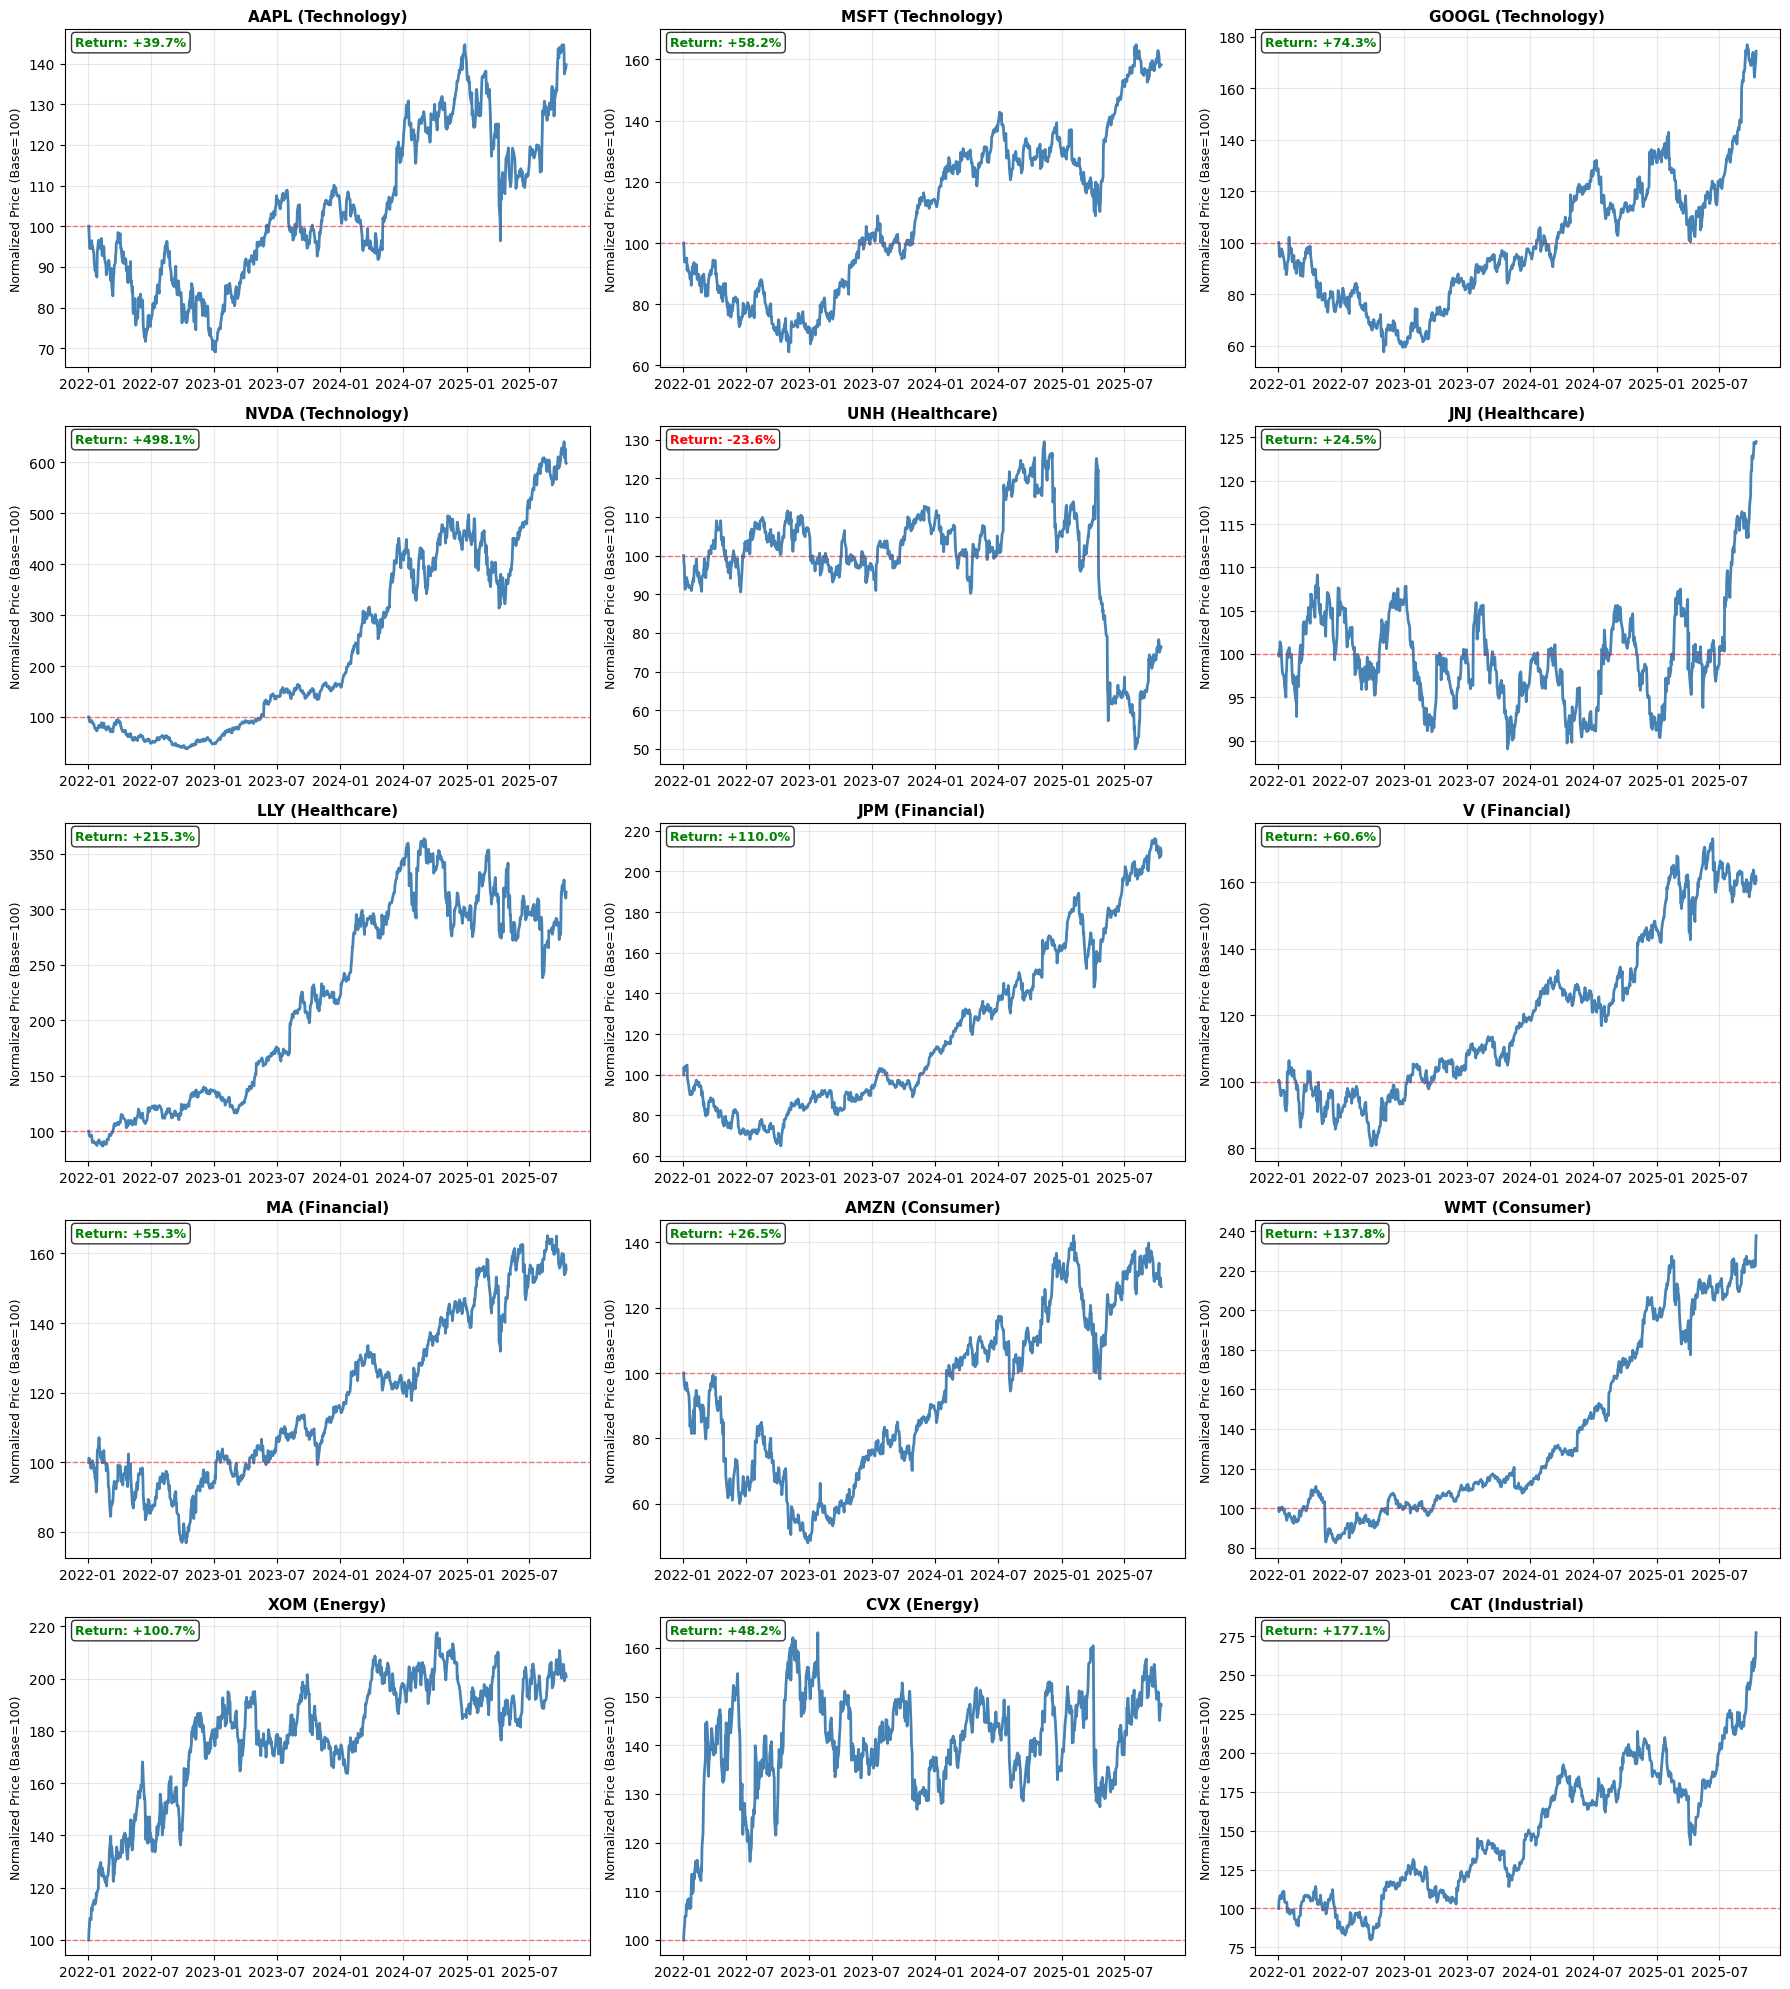


--- Summary Statistics by Stock ---

Ticker     Sector  Start Price  End Price  Total Return (%)  Ann. Return (%)  Ann. Volatility (%)  Sharpe Ratio  Max Drawdown (%)  Avg Daily Volume  Trading Days
  AAPL Technology   178.443130 249.339996         39.730790         9.279990            29.044392      0.450168        -33.360516      6.565094e+07           950
  MSFT Technology   324.504639 513.429993         58.219616        12.942247            27.135350      0.584268        -35.578859      2.551736e+07           950
 GOOGL Technology   143.998322 251.029999         74.328420        15.884697            32.754373      0.614202        -43.628370      3.255278e+07           950
  NVDA Technology    30.064438 179.830002        498.148559        60.715893            54.724321      1.139119        -62.701692      4.158343e+08           950
   UNH Healthcare   472.636444 361.149994        -23.588204        -6.887763            32.018546     -0.057473        -61.390867      5.386881e+06     

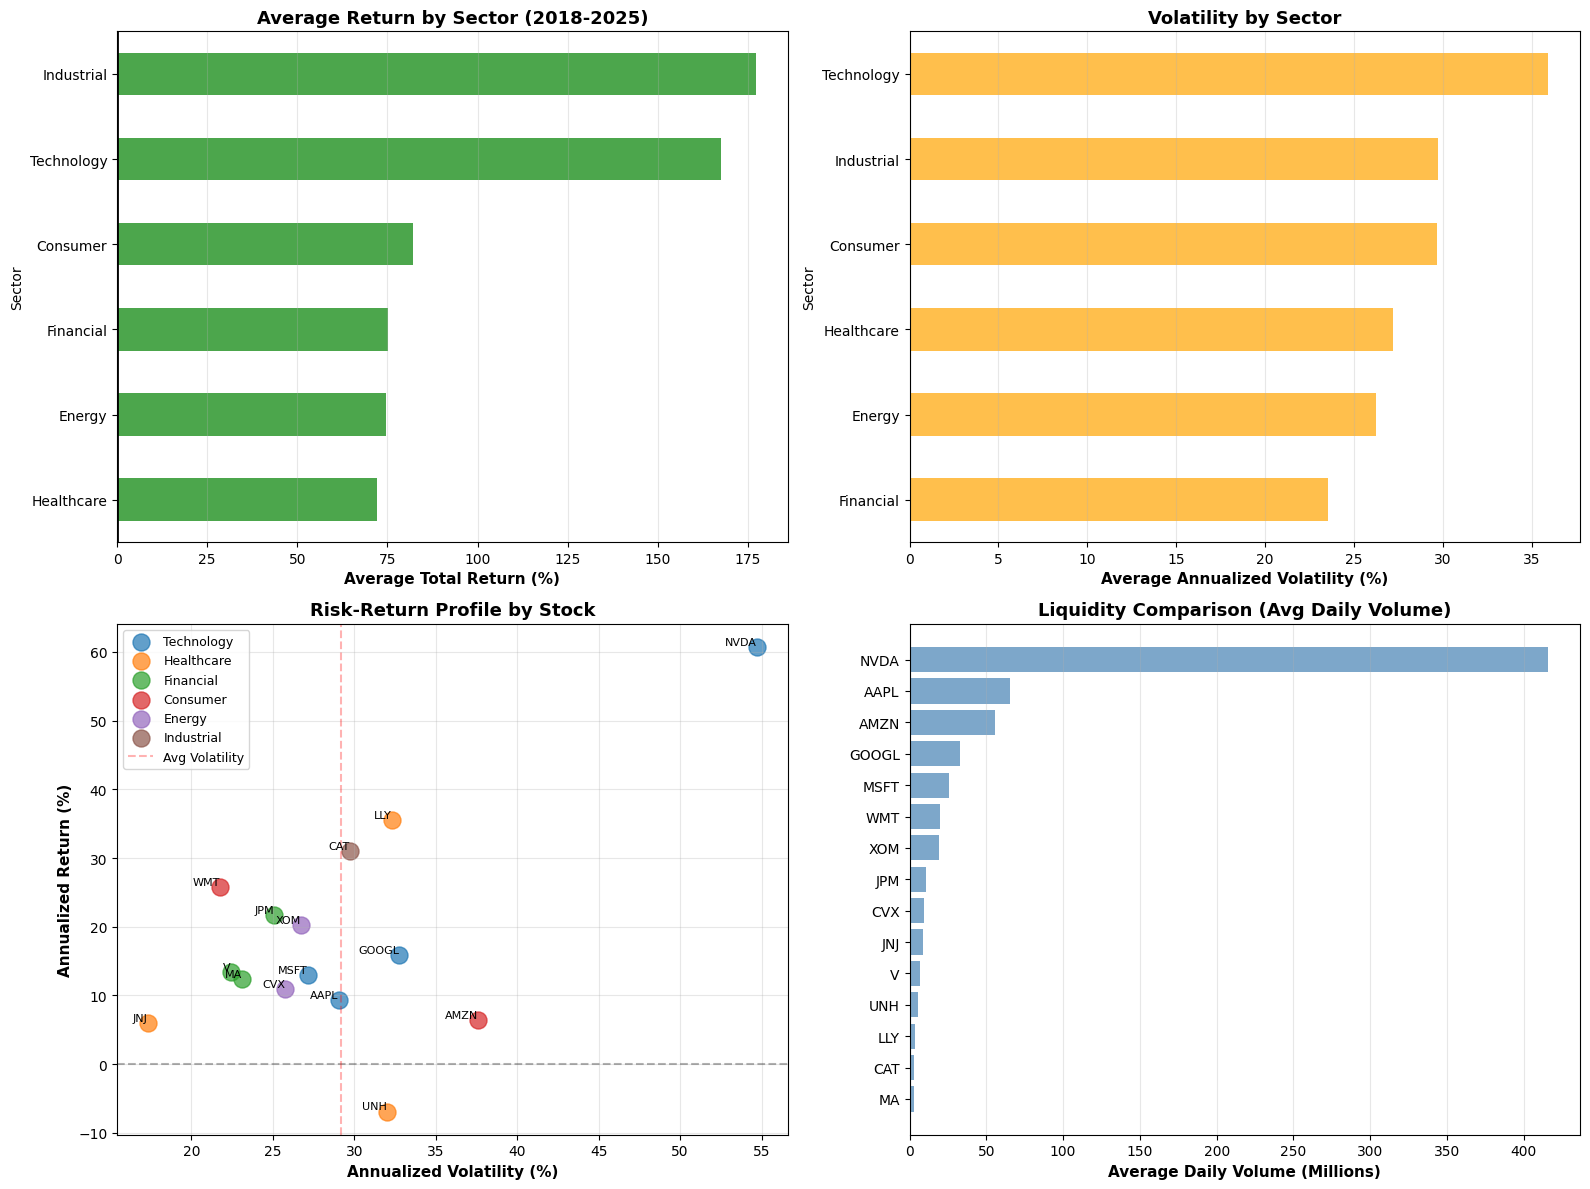


--- Correlation Analysis ---
✓ Saved: correlation_matrix.png


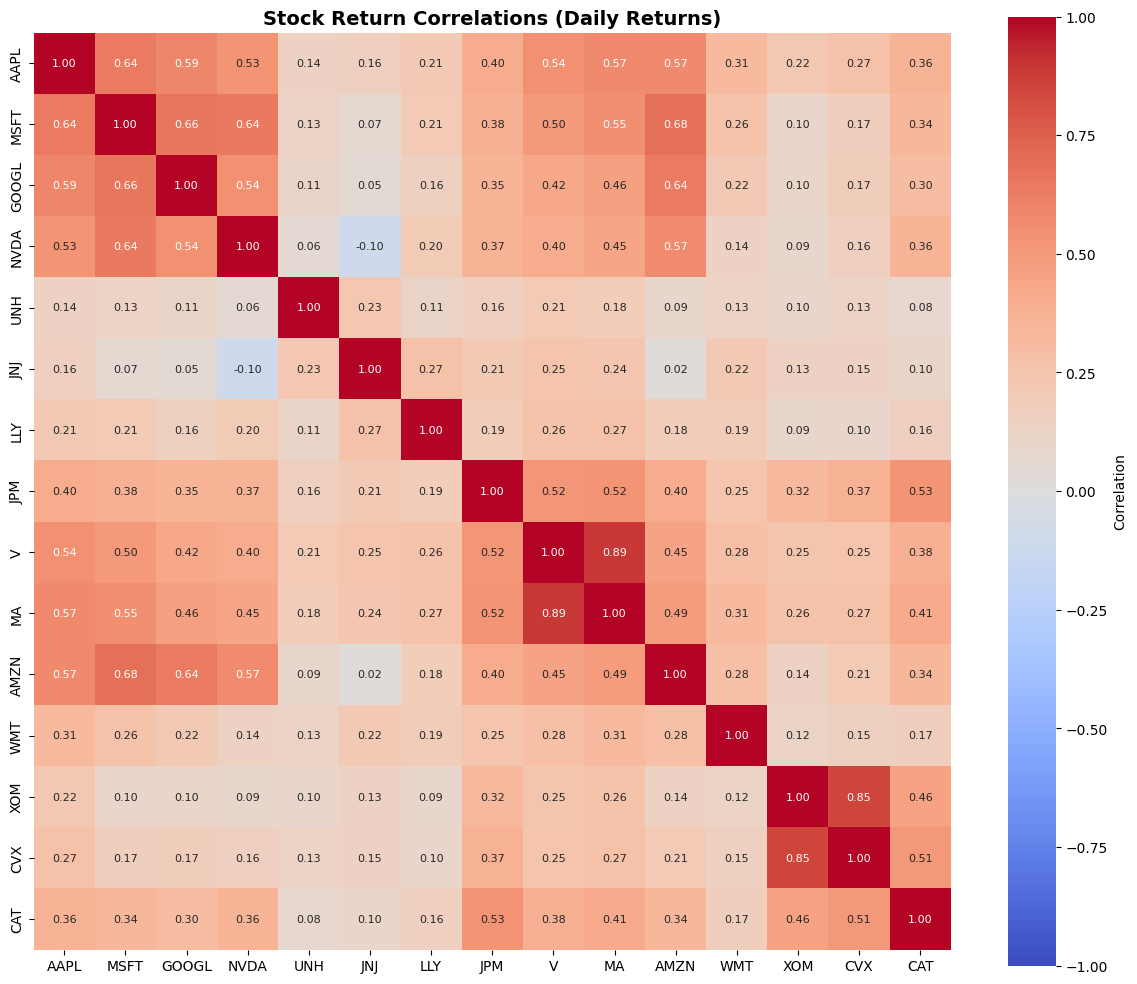


--- Highest Correlations (>0.7) ---
Stock 1 Stock 2  Correlation
      V      MA     0.886586
    XOM     CVX     0.846504

--- Target Variable Analysis ---
✓ Saved: return_distribution_analysis.png


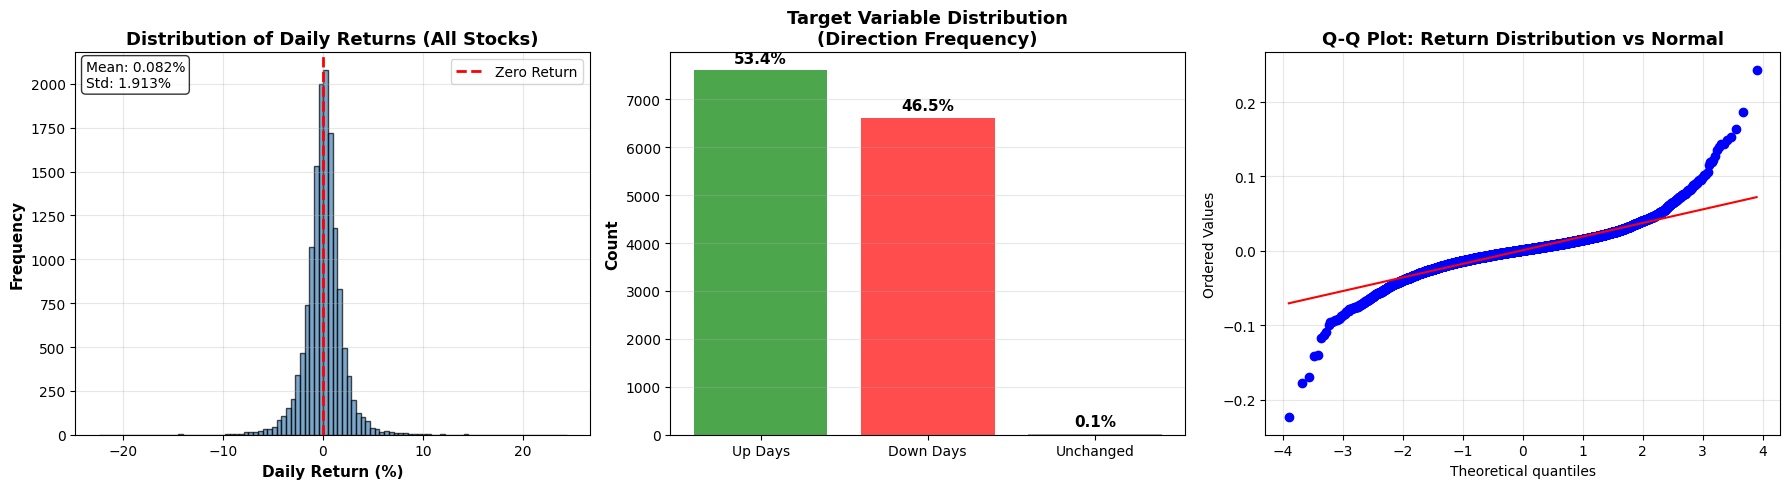


--- Return Statistics ---
  Total observations: 14,235
  Up days: 7,604 (53.42%)
  Down days: 6,615 (46.47%)
  Unchanged: 16 (0.11%)
  Mean daily return: 0.0822%
  Std daily return: 1.9128%
  Skewness: 0.1607
  Kurtosis: 10.2080
  Min return: -22.38%
  Max return: 24.37%

EXPLORATORY DATA ANALYSIS SUMMARY

📊 Dataset Characteristics:
  • Total samples: 14,250 records
  • Stocks: 15 across 6 sectors
  • Time period: 2022-01-03 to 2025-10-15
  • Average trading days per stock: 950

📈 Performance Summary:
  • Best performer: NVDA (498.1%)
  • Worst performer: UNH (-23.6%)
  • Average return: 106.9%
  • Average volatility: 29.2%

🎯 Target Variable Balance:
  • Up days: 53.42% (n=7,604)
  • Down days: 46.47% (n=6,615)
  • Balance is near 50/50 ✓ (good for binary classification)

🔗 Diversification:
  • Average correlation: 0.298
  • Low correlation suggests good diversification ✓

📁 Files Generated:
  • stock_price_trends.png - Individual stock normalized prices
  • sector_analysis.png - Sec

In [6]:
# ==============================================================================
# SECTION 2.2: EXPLORATORY DATA ANALYSIS
# ==============================================================================

print("\n" + "="*80)
print("SECTION 2.2: EXPLORATORY DATA ANALYSIS")
print("="*80)

# -------------------------------------------------------------------------
# 2.2.1: Stock Price Trends
# -------------------------------------------------------------------------

print("\n--- Analyzing Stock Price Trends ---")

fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.flatten()

for idx, (ticker, sector) in enumerate(STOCK_UNIVERSE.items()):
    ax = axes[idx]

    # Get stock data
    stock_data = raw_data[raw_data['ticker'] == ticker].copy()

    # Normalize to 100 at start for comparison
    stock_data['normalized'] = (stock_data['Close'] / stock_data['Close'].iloc[0]) * 100

    # Plot
    ax.plot(stock_data.index, stock_data['normalized'], linewidth=2, color='steelblue')
    ax.axhline(y=100, color='red', linestyle='--', alpha=0.5, linewidth=1)
    ax.set_title(f'{ticker} ({sector})', fontweight='bold', fontsize=11)
    ax.set_ylabel('Normalized Price (Base=100)', fontsize=9)
    ax.grid(alpha=0.3)

    # Calculate returns
    total_return = ((stock_data['Close'].iloc[-1] / stock_data['Close'].iloc[0]) - 1) * 100

    # Color based on performance
    color = 'green' if total_return > 0 else 'red'
    ax.text(0.02, 0.98, f'Return: {total_return:+.1f}%',
            transform=ax.transAxes, fontsize=9, fontweight='bold',
            verticalalignment='top', color=color,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('stock_price_trends.png', dpi=300, bbox_inches='tight')
print("✓ Saved: stock_price_trends.png")
plt.show()

# -------------------------------------------------------------------------
# 2.2.2: Summary Statistics by Stock
# -------------------------------------------------------------------------

print("\n--- Summary Statistics by Stock ---")

stock_stats = []

for ticker in STOCK_UNIVERSE.keys():
    stock_data = raw_data[raw_data['ticker'] == ticker].copy()

    # Calculate statistics
    returns = stock_data['Close'].pct_change().dropna()

    stats = {
        'Ticker': ticker,
        'Sector': STOCK_UNIVERSE[ticker],
        'Start Price': stock_data['Close'].iloc[0],
        'End Price': stock_data['Close'].iloc[-1],
        'Total Return (%)': ((stock_data['Close'].iloc[-1] / stock_data['Close'].iloc[0]) - 1) * 100,
        'Ann. Return (%)': (((stock_data['Close'].iloc[-1] / stock_data['Close'].iloc[0]) ** (252 / len(stock_data))) - 1) * 100,
        'Ann. Volatility (%)': returns.std() * np.sqrt(252) * 100,
        'Sharpe Ratio': (returns.mean() * 252) / (returns.std() * np.sqrt(252)),
        'Max Drawdown (%)': ((stock_data['Close'] / stock_data['Close'].cummax()) - 1).min() * 100,
        'Avg Daily Volume': stock_data['Volume'].mean(),
        'Trading Days': len(stock_data)
    }

    stock_stats.append(stats)

stats_df = pd.DataFrame(stock_stats)

print("\n" + stats_df.to_string(index=False))

# Save to CSV
stats_df.to_csv('stock_summary_statistics.csv', index=False)
print("\n✓ Saved: stock_summary_statistics.csv")

# -------------------------------------------------------------------------
# 2.2.3: Sector Comparison
# -------------------------------------------------------------------------

print("\n--- Sector-Level Analysis ---")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Average Return by Sector
ax = axes[0, 0]
sector_returns = stats_df.groupby('Sector')['Total Return (%)'].mean().sort_values()
colors = ['red' if x < 0 else 'green' for x in sector_returns.values]
sector_returns.plot(kind='barh', ax=ax, color=colors, alpha=0.7)
ax.set_xlabel('Average Total Return (%)', fontweight='bold', fontsize=11)
ax.set_title('Average Return by Sector (2018-2025)', fontweight='bold', fontsize=13)
ax.axvline(x=0, color='black', linewidth=2)
ax.grid(axis='x', alpha=0.3)

# Plot 2: Volatility by Sector
ax = axes[0, 1]
sector_vol = stats_df.groupby('Sector')['Ann. Volatility (%)'].mean().sort_values()
sector_vol.plot(kind='barh', ax=ax, color='orange', alpha=0.7)
ax.set_xlabel('Average Annualized Volatility (%)', fontweight='bold', fontsize=11)
ax.set_title('Volatility by Sector', fontweight='bold', fontsize=13)
ax.grid(axis='x', alpha=0.3)

# Plot 3: Risk-Return Scatter
ax = axes[1, 0]
for sector in stats_df['Sector'].unique():
    sector_data = stats_df[stats_df['Sector'] == sector]
    ax.scatter(sector_data['Ann. Volatility (%)'], sector_data['Ann. Return (%)'],
              s=150, alpha=0.7, label=sector)

    # Add ticker labels
    for _, row in sector_data.iterrows():
        ax.annotate(row['Ticker'],
                   (row['Ann. Volatility (%)'], row['Ann. Return (%)']),
                   fontsize=8, ha='right', va='bottom')

ax.set_xlabel('Annualized Volatility (%)', fontweight='bold', fontsize=11)
ax.set_ylabel('Annualized Return (%)', fontweight='bold', fontsize=11)
ax.set_title('Risk-Return Profile by Stock', fontweight='bold', fontsize=13)
ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax.axvline(x=stats_df['Ann. Volatility (%)'].mean(), color='red',
          linestyle='--', alpha=0.3, label='Avg Volatility')
ax.legend(fontsize=9, loc='best')
ax.grid(alpha=0.3)

# Plot 4: Trading Volume Comparison
ax = axes[1, 1]
volume_data = stats_df.sort_values('Avg Daily Volume', ascending=True)
ax.barh(volume_data['Ticker'], volume_data['Avg Daily Volume'] / 1e6,
       color='steelblue', alpha=0.7)
ax.set_xlabel('Average Daily Volume (Millions)', fontweight='bold', fontsize=11)
ax.set_title('Liquidity Comparison (Avg Daily Volume)', fontweight='bold', fontsize=13)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('sector_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Saved: sector_analysis.png")
plt.show()

# -------------------------------------------------------------------------
# 2.2.4: Correlation Analysis
# -------------------------------------------------------------------------

print("\n--- Correlation Analysis ---")

# Create returns matrix
returns_matrix = pd.DataFrame()

for ticker in STOCK_UNIVERSE.keys():
    stock_data = raw_data[raw_data['ticker'] == ticker].copy()
    returns = stock_data['Close'].pct_change()
    returns_matrix[ticker] = returns

# Remove first row (NaN from pct_change)
returns_matrix = returns_matrix.dropna()

# Calculate correlation matrix
corr_matrix = returns_matrix.corr()

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
           center=0, vmin=-1, vmax=1, square=True, ax=ax,
           cbar_kws={'label': 'Correlation'}, annot_kws={'fontsize': 8})
ax.set_title('Stock Return Correlations (Daily Returns)',
            fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
print("✓ Saved: correlation_matrix.png")
plt.show()

# Print high correlations
print("\n--- Highest Correlations (>0.7) ---")
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.7:
            high_corr.append({
                'Stock 1': corr_matrix.columns[i],
                'Stock 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if high_corr:
    high_corr_df = pd.DataFrame(high_corr).sort_values('Correlation', ascending=False)
    print(high_corr_df.to_string(index=False))
else:
    print("No correlations above 0.7 (indicating good diversification)")

# -------------------------------------------------------------------------
# 2.2.5: Target Variable Distribution Analysis
# -------------------------------------------------------------------------

print("\n--- Target Variable Analysis ---")

# Calculate daily returns for all stocks
all_returns = []
for ticker in STOCK_UNIVERSE.keys():
    stock_data = raw_data[raw_data['ticker'] == ticker].copy()
    returns = stock_data['Close'].pct_change().dropna()
    all_returns.extend(returns.values)

all_returns = np.array(all_returns)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Return Distribution
ax = axes[0]
ax.hist(all_returns * 100, bins=100, alpha=0.7, color='steelblue', edgecolor='black')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Return')
ax.set_xlabel('Daily Return (%)', fontweight='bold', fontsize=11)
ax.set_ylabel('Frequency', fontweight='bold', fontsize=11)
ax.set_title('Distribution of Daily Returns (All Stocks)', fontweight='bold', fontsize=13)
ax.legend()
ax.grid(alpha=0.3)

# Add statistics
mean_return = np.mean(all_returns) * 100
std_return = np.std(all_returns) * 100
ax.text(0.02, 0.98, f'Mean: {mean_return:.3f}%\nStd: {std_return:.3f}%',
       transform=ax.transAxes, fontsize=10, verticalalignment='top',
       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Plot 2: Up/Down Day Distribution
ax = axes[1]
up_days = np.sum(all_returns > 0)
down_days = np.sum(all_returns < 0)
unchanged = np.sum(all_returns == 0)

ax.bar(['Up Days', 'Down Days', 'Unchanged'],
      [up_days, down_days, unchanged],
      color=['green', 'red', 'gray'], alpha=0.7)
ax.set_ylabel('Count', fontweight='bold', fontsize=11)
ax.set_title('Target Variable Distribution\n(Direction Frequency)',
            fontweight='bold', fontsize=13)

# Add percentages
total = len(all_returns)
for i, (label, count) in enumerate(zip(['Up Days', 'Down Days', 'Unchanged'],
                                       [up_days, down_days, unchanged])):
    percentage = (count / total) * 100
    ax.text(i, count + 100, f'{percentage:.1f}%',
           ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.grid(axis='y', alpha=0.3)

# Plot 3: Q-Q Plot (Check Normality)
ax = axes[2]
from scipy import stats
stats.probplot(all_returns, dist="norm", plot=ax)
ax.set_title('Q-Q Plot: Return Distribution vs Normal',
            fontweight='bold', fontsize=13)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('return_distribution_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Saved: return_distribution_analysis.png")
plt.show()

print(f"\n--- Return Statistics ---")
print(f"  Total observations: {len(all_returns):,}")
print(f"  Up days: {up_days:,} ({up_days/total*100:.2f}%)")
print(f"  Down days: {down_days:,} ({down_days/total*100:.2f}%)")
print(f"  Unchanged: {unchanged:,} ({unchanged/total*100:.2f}%)")
print(f"  Mean daily return: {mean_return:.4f}%")
print(f"  Std daily return: {std_return:.4f}%")
print(f"  Skewness: {stats.skew(all_returns):.4f}")
print(f"  Kurtosis: {stats.kurtosis(all_returns):.4f}")
print(f"  Min return: {np.min(all_returns)*100:.2f}%")
print(f"  Max return: {np.max(all_returns)*100:.2f}%")

# -------------------------------------------------------------------------
# 2.2.6: Summary for Report
# -------------------------------------------------------------------------

print("\n" + "="*80)
print("EXPLORATORY DATA ANALYSIS SUMMARY")
print("="*80)

print("\n📊 Dataset Characteristics:")
print(f"  • Total samples: {len(raw_data):,} records")
print(f"  • Stocks: {len(STOCK_UNIVERSE)} across {len(set(STOCK_UNIVERSE.values()))} sectors")
print(f"  • Time period: {raw_data.index.min().date()} to {raw_data.index.max().date()}")
print(f"  • Average trading days per stock: {len(raw_data) / len(STOCK_UNIVERSE):.0f}")

print("\n📈 Performance Summary:")
print(f"  • Best performer: {stats_df.nlargest(1, 'Total Return (%)').iloc[0]['Ticker']} "
      f"({stats_df.nlargest(1, 'Total Return (%)').iloc[0]['Total Return (%)']:.1f}%)")
print(f"  • Worst performer: {stats_df.nsmallest(1, 'Total Return (%)').iloc[0]['Ticker']} "
      f"({stats_df.nsmallest(1, 'Total Return (%)').iloc[0]['Total Return (%)']:.1f}%)")
print(f"  • Average return: {stats_df['Total Return (%)'].mean():.1f}%")
print(f"  • Average volatility: {stats_df['Ann. Volatility (%)'].mean():.1f}%")

print("\n🎯 Target Variable Balance:")
print(f"  • Up days: {up_days/total*100:.2f}% (n={up_days:,})")
print(f"  • Down days: {down_days/total*100:.2f}% (n={down_days:,})")
print(f"  • Balance is near 50/50 ✓ (good for binary classification)")

print("\n🔗 Diversification:")
avg_corr = corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)].mean()
print(f"  • Average correlation: {avg_corr:.3f}")
if avg_corr < 0.5:
    print(f"  • Low correlation suggests good diversification ✓")
elif avg_corr < 0.7:
    print(f"  • Moderate correlation - reasonable diversification ✓")
else:
    print(f"  • High correlation - stocks move together")

print("\n📁 Files Generated:")
print("  • stock_price_trends.png - Individual stock normalized prices")
print("  • sector_analysis.png - Sector-level comparisons")
print("  • correlation_matrix.png - Return correlation heatmap")
print("  • return_distribution_analysis.png - Target variable distribution")
print("  • stock_summary_statistics.csv - Detailed statistics table")

print("\n✅ Exploratory Data Analysis Complete!")
print("="*80)


### 2.3 Data Cleaning

In [7]:

def clean_stock_data(df):
    """
    Clean and validate OHLCV data for multiple stocks

    Steps:
    1. Validate OHLC relationships (Remove impossible values)
    2. Handle missing values (forward fill max 3 days per stock)
    3. Calculate basic returns
    4. Remove outliers
    """
    print("\nCleaning data...")

    # Initialize list to store cleaned data
    cleaned_stocks = []

    # Process each stock separately
    for ticker in df['ticker'].unique():
        # Create a copy of the stock data
        stock_data = df[df['ticker'] == ticker].copy()

        # Sort by date
        stock_data = stock_data.sort_index()

        # Check for impossible values
        bad_mask = (
            (stock_data['Low'] > stock_data['High']) |
            (stock_data['Open'] < stock_data['Low']) |
            (stock_data['Open'] > stock_data['High']) |
            (stock_data['Close'] < stock_data['Low']) |
            (stock_data['Close'] > stock_data['High']) |
            (stock_data['Volume'] <= 0)
        )

        if bad_mask.any():
            print(f"  {ticker}: Found {bad_mask.sum()} impossible values, setting to NaN")
            stock_data.loc[bad_mask, ['Open', 'High', 'Low', 'Close', 'Volume']] = np.nan

        # Forward fill short gaps (max 3 days)
        stock_data[['Open', 'High', 'Low', 'Close', 'Volume']] = \
            stock_data[['Open', 'High', 'Low', 'Close', 'Volume']].fillna(method='ffill', limit=3)

        # Calculate returns
        stock_data['returns'] = np.log(stock_data['Close'] / stock_data['Close'].shift(1))
        stock_data['returns_oc'] = np.log(stock_data['Close'] / stock_data['Open'])
        stock_data['returns_hl'] = np.log(stock_data['High'] / stock_data['Low'])

        # Drop remaining NaN
        stock_data = stock_data.dropna()

        cleaned_stocks.append(stock_data)

    # Combine all cleaned stocks into a single DataFrame by concatenating them along the rows
    result = pd.concat(cleaned_stocks, axis=0)

    # Sort the result by the index (dates)
    result = result.sort_index()

    print(f"\n✓ Cleaning complete:")
    print(f"  Records before: {len(df):,}")

    print(f"  Records after: {len(result):,}")
    print(f"  Dropped: {len(df) - len(result):,} ({(len(df)-len(result))/len(df)*100:.1f}%)")

    return result

# Clean the data
clean_data = clean_stock_data(raw_data)

# Verify data quality
print(f"\nData Quality Check:")
print(f"  Missing values: {clean_data.isnull().sum().sum()}")
print(f"  Infinite values: {np.isinf(clean_data.select_dtypes(include=[np.number]).values).sum()}")
print(f"  Unique stocks: {clean_data['ticker'].nunique()}")
print(f"  Date range: {clean_data.index.min().date()} to {clean_data.index.max().date()}")

# Display sample
print("\nSample data:")
print(clean_data.head())



Cleaning data...

✓ Cleaning complete:
  Records before: 14,250
  Records after: 14,235
  Dropped: 15 (0.1%)

Data Quality Check:
  Missing values: 0
  Infinite values: 0
  Unique stocks: 15
  Date range: 2022-01-04 to 2025-10-15

Sample data:
                 Close        High         Low        Open    Volume ticker  \
Date                                                                          
2022-01-04  176.178391  179.354901  175.609755  179.050979  99310400   AAPL   
2022-01-04  167.522003  171.399994  166.349503  170.438004  70726000   AMZN   
2022-01-04  143.410385  145.481595  142.732065  144.400050  28400000  GOOGL   
2022-01-04   45.018562   46.014045   44.942476   45.665308  33930000    WMT   
2022-01-04  151.102264  151.777511  147.861074  147.933101  20195800    JPM   

                sector   returns  returns_oc  returns_hl  
Date                                                      
2022-01-04  Technology -0.012773   -0.016173    0.021102  
2022-01-04    Consumer -

### 2.4: Feature Engineering - Building Multi-Scale Feature Set

In this section, we implement **comprehensive feature engineering** to create a pool of over 100 features per stock for robust and flexible predictive modeling. The design logic behind this engineering can be summarized as follows:

- **Diverse Feature Categories:** Features are organized into momentum, volatility, volume, statistical, technical indicator, calendar, and interaction categories. This broad coverage aims to capture distinct market regularities and behaviors relevant to stock price movement.

- **Multi-Scale Temporal Analysis:** For each feature, values are computed over a wide set of rolling windows, ranging from short-term (5 days) to long-term (200 days). This multi-horizon approach allows the model to capture both immediate reactions and long-range trends.

- **Bias Avoidance & Realism:** All features use shifting (typically by 1 period) to ensure only information available at prediction time is present, **eliminating look-ahead bias.**

- **OHLCV Decomposition:** Raw price (Open/High/Low/Close) and Volume data are decomposed into signals spanning averages (SMA/EMA), ranges, ratios, rate of change, and crossovers, exposing nuanced patterns in trading and volatility structure.

- **Volume & Price Interactions:** Explicit interaction features (e.g., price-volume correlation, volatility-adjusted momentum) detect market conviction and risk-adjusted opportunities that single modalities may miss.

- **Technical Indicators:** Widely-recognized strategies (RSI, MACD, Stochastic, Williams %R, Bollinger Bands, etc.) are included for their empirical value in capturing regime shifts, reversals, and trend strength.

- **Calendar & Structural Effects:** Day-of-week/month, quarter, and period-end flags encode known calendar anomalies (like end-of-month effects) and seasonality, which are prominent in financial time series.

- **Statistical Moments & Relativity:** Rolling statistics (mean, std, skew, kurtosis) and measures like price percentile or % from high/low provide distributional and context-dependent information.

- **Quality & Robustness:** All NaN and inf values are aggressively cleaned post-calculation, and every feature is engineered for each stock independently to preserve data integrity.

The overall objective is to maximize predictive signal extraction while minimizing spurious correlation and look-ahead risk, producing a rich, high-dimensional dataset amenable to modern model selection and interpretability techniques.


In [8]:
# ==============================================================================
# SECTION 2.4: COMPREHENSIVE FEATURE ENGINEERING (100+ FEATURES)
# ==============================================================================
print("\nGoal: Create 100+ features as pool for selection")
print("Time scales: 5d, 10d, 14d, 20d, 30d, 60d, 100d, 200d")

def engineer_multi_scale_features(df, shift_by=1):
    """
    Create comprehensive multi-scale temporal features

    CRITICAL: All features use shift(shift_by) to avoid look-ahead bias

    Returns features for each stock separately to maintain independence
    """
    print("\nEngineering features per stock...")

    all_features = []
    feature_names = None

    for ticker in df['ticker'].unique():
        stock_data = df[df['ticker'] == ticker].copy()

        features = pd.DataFrame(index=stock_data.index)
        features['ticker'] = ticker
        features['sector'] = stock_data['sector'].iloc[0]

        # Extract OHLCV
        close = stock_data['Close']
        high = stock_data['High']
        low = stock_data['Low']
        open_price = stock_data['Open']
        volume = stock_data['Volume']
        returns = stock_data['returns']

        feature_count = 0

        # =====================================================================
        # 1. MOMENTUM FEATURES
        # =====================================================================

        for window in [5, 10, 14, 20, 30, 60, 100, 200]:
            # Calculate raw values first (unshifted)
            sma_raw = close.rolling(window).mean()
            ema_raw = close.ewm(span=window, adjust=False).mean()

            # SMA: Simple moving average, captures price trend and smooths short-term fluctuations
            features[f'sma_{window}'] = sma_raw.shift(shift_by)

            # EMA: Exponential moving average, similar but puts more weight on recent prices
            features[f'ema_{window}'] = ema_raw.shift(shift_by)

            # Price to MA ratio: Measures how stretched current price is vs. mid-term trend
            features[f'price_to_sma_{window}'] = (close / sma_raw).shift(shift_by)

            # ROC: Rate of change (%), measures price momentum over the window
            features[f'roc_{window}'] = (close.pct_change(window) * 100).shift(shift_by)

            # Momentum: Raw price difference over the window, another measure of recent trend
            features[f'momentum_{window}'] = (close - close.shift(window)).shift(shift_by)

            feature_count += 5

        # MA crossovers (need to recalculate raw values)
        sma_20_raw = close.rolling(20).mean()
        sma_50_raw = close.rolling(50).mean()
        sma_200_raw = close.rolling(200).mean()
        ema_10_raw = close.ewm(span=10, adjust=False).mean()
        ema_30_raw = close.ewm(span=30, adjust=False).mean()

        # MA Crossover ratios: capture regime shift and bullish/bearish structure
        features['sma_cross_20_50'] = (sma_20_raw / sma_50_raw).shift(shift_by)      # <1: short-term below mid-term, >1: above
        features['sma_cross_50_200'] = (sma_50_raw / sma_200_raw).shift(shift_by)
        features['ema_cross_10_30'] = (ema_10_raw / ema_30_raw).shift(shift_by)
        feature_count += 3

        # =====================================================================
        # 2. VOLATILITY FEATURES
        # =====================================================================

        # Rolling volatility: standard deviation of daily log returns, measures risk (recent variability)
        for window in [5, 10, 20, 30, 60]:
            features[f'volatility_{window}'] = returns.rolling(window).std().shift(shift_by)
            feature_count += 1

        # ATR: Average true range, captures volatility using both price movement and gaps
        for window in [7, 14, 21]:
            high_low = high - low
            high_close = np.abs(high - close.shift(1))
            low_close = np.abs(low - close.shift(1))
            true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
            features[f'atr_{window}'] = true_range.rolling(window).mean().shift(shift_by)
            feature_count += 1

        # Bollinger Bands: Width and normalized close position, detect volatility regimes and mean reversion
        for window in [10, 20, 30]:
            bb_ma_raw = close.rolling(window).mean()
            bb_std_raw = close.rolling(window).std()
            bb_upper_raw = bb_ma_raw + 2 * bb_std_raw
            bb_lower_raw = bb_ma_raw - 2 * bb_std_raw

            # BB width: width/center, shows how "wide" price excursions are (volatility)
            features[f'bb_width_{window}'] = ((bb_upper_raw - bb_lower_raw) / bb_ma_raw).shift(shift_by)
            # BB position: close location between bands [0, 1], for overbought/oversold signal
            features[f'bb_position_{window}'] = ((close - bb_lower_raw) / (bb_upper_raw - bb_lower_raw + 1e-10)).shift(shift_by)
            feature_count += 2

        # High-Low range: Mean candle range, another simple volatility proxy
        for window in [5, 10, 20]:
            features[f'hl_range_{window}'] = (high - low).rolling(window).mean().shift(shift_by)
            feature_count += 1

        # =====================================================================
        # 3. VOLUME FEATURES
        # =====================================================================

        # Volume moving average and ratio: detect abnormal volume surges or drops
        for window in [5, 10, 20, 50]:
            vol_ma_raw = volume.rolling(window).mean()
            # Volume MA: Typical traded shares
            features[f'volume_ma_{window}'] = vol_ma_raw.shift(shift_by)
            # Volume ratio: Current volume compared to running average
            features[f'volume_ratio_{window}'] = (volume / vol_ma_raw).shift(shift_by)
            feature_count += 2

        # Volume ROC: % change in traded volume, abnormal activity
        for window in [5, 10, 20]:
            features[f'volume_roc_{window}'] = (volume.pct_change(window) * 100).shift(shift_by)
            feature_count += 1

        # OBV: On-balance volume, accumulates volume with price direction for demand/supply pressure
        obv = (volume * np.sign(close.diff())).cumsum()
        features['obv'] = obv.shift(shift_by)
        # OBV MA: Smooth OBV changes to find bigger trends in volume
        features['obv_ma_20'] = obv.rolling(20).mean().shift(shift_by)
        feature_count += 2

        # Volume-Price correlation: Measures relation between price and volume movement for accumulation/distribution
        for window in [20, 60]:
            price_change = close.pct_change()
            vol_change = volume.pct_change()
            features[f'vol_price_corr_{window}'] = price_change.rolling(window).corr(vol_change).shift(shift_by)
            feature_count += 1

        # =====================================================================
        # 4. STATISTICAL FEATURES
        # =====================================================================

        # Lagged returns: Past returns over various lags, fundamental for model memory/AR processes
        for lag in [1, 2, 3, 5, 10, 20]:
            features[f'return_lag_{lag}'] = returns.shift(lag)
            feature_count += 1

        # Rolling mean, std, skew, kurtosis for returns: capturing trend, volatility, asymmetry, tail risk
        for window in [10, 20, 60]:
            # Mean return (trend direction)
            features[f'return_mean_{window}'] = returns.rolling(window).mean().shift(shift_by)
            # Std return (volatility)
            features[f'return_std_{window}'] = returns.rolling(window).std().shift(shift_by)
            # Skewness (asymmetry of return distribution)
            features[f'return_skew_{window}'] = returns.rolling(window).skew().shift(shift_by)
            # Kurtosis (fat tail risk/outlier-prone returns)
            features[f'return_kurt_{window}'] = returns.rolling(window).kurt().shift(shift_by)
            feature_count += 4

        # Price percentile in range: Where does price sit in its N-day min/max range? Indicates breakout/mean reversion
        for window in [10, 20, 60, 100]:
            roll_min = close.rolling(window).min()
            roll_max = close.rolling(window).max()
            features[f'price_percentile_{window}'] = ((close - roll_min) / (roll_max - roll_min + 1e-10)).shift(shift_by)
            feature_count += 1

        # % from high/low: Measures proximity to multi-week/month highs/lows for momentum/mean reversion signals
        for window in [20, 60, 200]:
            roll_max = close.rolling(window).max()
            roll_min = close.rolling(window).min()
            features[f'pct_from_high_{window}'] = ((close - roll_max) / roll_max).shift(shift_by)
            features[f'pct_from_low_{window}'] = ((close - roll_min) / roll_min).shift(shift_by)
            feature_count += 2

        # =====================================================================
        # 5. TECHNICAL INDICATORS
        # =====================================================================

        # RSI: Relative Strength Index. Oscillator measuring speed/magnitude of recent price changes [overbought/oversold]
        for period in [7, 14, 21]:
            delta = close.diff()
            gain = delta.clip(lower=0).rolling(period).mean()
            loss = -delta.clip(upper=0).rolling(period).mean()
            rs = gain / (loss + 1e-10)
            features[f'rsi_{period}'] = (100 - 100/(1 + rs)).shift(shift_by)
            feature_count += 1

        # MACD: Difference of fast and slow EMAs. Captures mid-term trend change acceleration
        ema_12 = close.ewm(span=12, adjust=False).mean()
        ema_26 = close.ewm(span=26, adjust=False).mean()
        macd_line = ema_12 - ema_26
        macd_signal = macd_line.ewm(span=9, adjust=False).mean()
        features['macd_line'] = macd_line.shift(shift_by)              # MACD line (trend up/down)
        features['macd_signal'] = macd_signal.shift(shift_by)          # Signal line (smoothed MACD)
        features['macd_hist'] = (macd_line - macd_signal).shift(shift_by) # Histogram: signal cross strength
        feature_count += 3

        # Stochastic Oscillator: Percentile of close within high-low range, detects momentum and reversal signals
        for period in [14, 21]:
            low_min = low.rolling(period).min()
            high_max = high.rolling(period).max()
            stoch = 100 * (close - low_min) / (high_max - low_min + 1e-10)
            features[f'stochastic_{period}'] = stoch.shift(shift_by)
            feature_count += 1

        # Williams %R: Similar to stochastic, but inverted: tells overbought/oversold
        for period in [14, 21]:
            high_max = high.rolling(period).max()
            low_min = low.rolling(period).min()
            williams = -100 * (high_max - close) / (high_max - low_min + 1e-10)
            features[f'williams_r_{period}'] = williams.shift(shift_by)
            feature_count += 1

        # =====================================================================
        # 6. CALENDAR FEATURES
        # =====================================================================

        # Day of week (0=Monday), captures weekly calendar effects
        features['day_of_week'] = stock_data.index.dayofweek
        # Day of month [1-31], for calendar effects, e.g. end-of-month rebalancing
        features['day_of_month'] = stock_data.index.day
        # Month [1-12], for seasonality
        features['month'] = stock_data.index.month
        # Quarter [1-4], for quarterly earnings effects
        features['quarter'] = stock_data.index.quarter
        # Month-end flag (1=month ends), for rebalancing/surprises
        features['is_month_end'] = stock_data.index.is_month_end.astype(int)
        # Month-start flag (1=first trading day)
        features['is_month_start'] = stock_data.index.is_month_start.astype(int)
        # Quarter-end flag (1=quarter ends), captures quarterly market patterns
        features['is_quarter_end'] = stock_data.index.is_quarter_end.astype(int)
        feature_count += 7

        # =====================================================================
        # 7. INTERACTION FEATURES
        # =====================================================================

        # Volatility regime: Compares short and mid-term vol, high value=volatility pick up (regime shift risk)
        vol_20 = returns.rolling(20).std()
        vol_60 = returns.rolling(60).std()
        features['vol_regime'] = (vol_20 / (vol_60 + 1e-10)).shift(shift_by)
        feature_count += 1

        # Trend strength: Normalized absolute difference between fast and slow MAs (for short and long trendiness)
        sma_20_raw = close.rolling(20).mean()
        sma_50_raw = close.rolling(50).mean()
        sma_200_raw = close.rolling(200).mean()

        # How strong is short-term trend vs. mid-term
        features['trend_strength_short'] = ((sma_20_raw - sma_50_raw).abs() / sma_20_raw).shift(shift_by)
        # How strong is mid-term vs. long-term
        features['trend_strength_long'] = ((sma_50_raw - sma_200_raw).abs() / sma_50_raw).shift(shift_by)
        feature_count += 2

        # Sharpe-like ratios: Momentum divided by volatility, normalized, for risk-adjusted return
        for period in [10, 20]:
            mom = close - close.shift(period)
            vol = returns.rolling(period).std()
            features[f'sharpe_{period}'] = (mom / (vol * np.sqrt(period) + 1e-10)).shift(shift_by)
            feature_count += 1

        # Price-Volume momentum: Combines price ROC and volume surge for identifying strong moves with confirmation
        roc_20_raw = close.pct_change(20) * 100
        vol_ma_20_raw = volume.rolling(20).mean()
        vol_ratio_20_raw = volume / vol_ma_20_raw
        features['pv_momentum_20'] = (roc_20_raw * vol_ratio_20_raw).shift(shift_by)
        feature_count += 1

        # Volatility-adjusted momentum: Price gain per unit of realized risk, for risk-aware momentum
        for period in [10, 20]:
            mom_raw = close - close.shift(period)
            vol_raw = returns.rolling(period).std()
            features[f'vol_adj_momentum_{period}'] = (mom_raw / vol_raw).shift(shift_by)
            feature_count += 1

        # =====================================================================
        # CLEAN UP
        # =====================================================================

        # Replace inf with NaN
        features = features.replace([np.inf, -np.inf], np.nan)

        # Drop rows with NaN
        features = features.dropna()

        if feature_names is None:
            # Store feature names (excluding metadata)
            feature_names = [col for col in features.columns if col not in ['ticker', 'sector']]

        all_features.append(features)

        print(f"  {ticker}: {len(features)} samples, {len(feature_names)} features")

    # Combine all stocks
    combined_features = pd.concat(all_features, axis=0)
    combined_features = combined_features.sort_index()

    print(f"\n✓ Feature engineering complete!")
    print(f"  Total features: {len(feature_names)}")
    print(f"  Total samples: {len(combined_features):,}")
    print(f"  ✓ Requirement met: 100+ features ({len(feature_names)} features)")
    print(f"  ✓ Requirement met: 10k+ samples ({len(combined_features):,} samples)")

    return combined_features, feature_names

# Create features
feature_data, feature_list = engineer_multi_scale_features(clean_data, shift_by=1)

print(f"\nFeature categories breakdown:")
categories = {
    'Momentum': len([f for f in feature_list if any(x in f for x in ['sma', 'ema', 'roc', 'momentum'])]),
    'Volatility': len([f for f in feature_list if any(x in f for x in ['volatility', 'atr', 'bb_', 'hl_range'])]),
    'Volume': len([f for f in feature_list if any(x in f for x in ['volume', 'obv'])]),
    'Statistical': len([f for f in feature_list if any(x in f for x in ['return_', 'percentile', 'pct_from'])]),
    'Technical': len([f for f in feature_list if any(x in f for x in ['rsi', 'macd', 'stochastic', 'williams'])]),
    'Calendar': len([f for f in feature_list if any(x in f for x in ['day_', 'month', 'quarter'])]),
    'Interaction': len([f for f in feature_list if any(x in f for x in ['regime', 'trend', 'sharpe', 'pv_', 'vol_adj'])])
}
for cat, count in categories.items():
    print(f"  {cat}: {count} features")


Goal: Create 100+ features as pool for selection
Time scales: 5d, 10d, 14d, 20d, 30d, 60d, 100d, 200d

Engineering features per stock...
  AAPL: 748 samples, 128 features
  AMZN: 748 samples, 128 features
  GOOGL: 748 samples, 128 features
  WMT: 748 samples, 128 features
  JPM: 748 samples, 128 features
  JNJ: 748 samples, 128 features
  V: 748 samples, 128 features
  LLY: 748 samples, 128 features
  CVX: 748 samples, 128 features
  MSFT: 748 samples, 128 features
  NVDA: 748 samples, 128 features
  CAT: 748 samples, 128 features
  XOM: 748 samples, 128 features
  MA: 748 samples, 128 features
  UNH: 748 samples, 128 features

✓ Feature engineering complete!
  Total features: 128
  Total samples: 11,220
  ✓ Requirement met: 100+ features (128 features)
  ✓ Requirement met: 10k+ samples (11,220 samples)

Feature categories breakdown:
  Momentum: 49 features
  Volatility: 17 features
  Volume: 13 features
  Statistical: 28 features
  Technical: 10 features
  Calendar: 7 features
  Inte

### 2.5 Target Variable Construction

In [9]:

# ==============================================================================
# SECTION 2.5: CREATE TARGET VARIABLE
# ==============================================================================

def create_target_per_stock(df):
    """
    Create binary target: 1 if next day closes higher, 0 otherwise
    Do this per stock to maintain independence
    """
    print("\nCreating targets per stock...")

    all_targets = []

    for ticker in df['ticker'].unique():
        stock_data = df[df['ticker'] == ticker].copy()

        # Creates a binary target variable that indicates whether the stock's closing price will increase the next day:
        # 1 if tomorrow's closing price is higher than today's, 0 otherwise.
        # The 'Close' column is shifted by -1 so that each row compares today's close with the next day's close.
        # If the future close is higher than today, the expression is True (1); otherwise, it's False (0).
        stock_data['target'] = (stock_data['Close'].shift(-1) > stock_data['Close']).astype(int)

        # Keep only date, ticker, and target
        target_df = stock_data[['ticker', 'target']].copy()

        all_targets.append(target_df)

    # Combine
    combined_targets = pd.concat(all_targets, axis=0)
    combined_targets = combined_targets.sort_index()

    return combined_targets

# Create targets with the clean_data
target_data = create_target_per_stock(clean_data)


# Merge feature_data and target_data to be merged_data
# which is the final dataset for feature selection

# Steps:
# 1. Reset index (converts date index → date column) for both feature_data and target_data
feature_data_reset = feature_data.reset_index()
target_data_reset = target_data.reset_index()

# 2. Get the ACTUAL column name (always first column after reset)
date_col = feature_data_reset.columns[0] # Always the first column after reset

# 3. Merge on both date and ticker using the actual column name
merged_data = feature_data_reset.merge(
    target_data_reset,
    on=[date_col, 'ticker'],  # ✓ Uses actual column name
    how='inner' # Inner join ensures only rows with matching dates and tickers are included
)

# 4. Set date back as index
merged_data = merged_data.set_index(date_col)

# Remove rows with NaN targets (last day of each stock)
merged_data = merged_data.dropna(subset=['target'])


print(f"\nTarget variable created:")
print(f"  Total samples: {len(merged_data):,}")
print(f"  Up days (1): {(merged_data['target']==1).sum():,} ({(merged_data['target']==1).mean()*100:.1f}%)")
print(f"  Down days (0): {(merged_data['target']==0).sum():,} ({(merged_data['target']==0).mean()*100:.1f}%)")

# Check balance per sector
print(f"\nTarget distribution by sector:")
for sector in merged_data['sector'].unique():
    sector_data = merged_data[merged_data['sector'] == sector]
    up_pct = (sector_data['target'] == 1).mean() * 100
    print(f"  {sector}: {up_pct:.1f}% up days")



Creating targets per stock...

Target variable created:
  Total samples: 11,220
  Up days (1): 6,095 (54.3%)
  Down days (0): 5,125 (45.7%)

Target distribution by sector:
  Technology: 54.4% up days
  Healthcare: 53.5% up days
  Consumer: 53.9% up days
  Energy: 53.0% up days
  Financial: 56.3% up days
  Industrial: 54.0% up days


## 3: Systematic Feature Selection



In this section, we perform systematic feature selection to identify the most informative predictors for our stock target classification task. We implement **Random Forest - Mean Decrease Accuracy (RF-MDA via permutation):** It measures the drop in model accuracy when each feature is permuted, thus quantifying its impact on predictions.

We prepare the data for selection by extracting our chosen features and target variable from the merged dataset. This section provides a comparative insight into which features are most predictive according to different methodologies.


In [ ]:
# ==============================================================================
# SECTION 3: FEATURE SELECTION IMPLEMENTATION
# ==============================================================================

# Prepare data for feature selection
# feature_list is a list of all the feature names from the feature_data constructed in the previous section
X_full = merged_data[feature_list].values
y_full = merged_data['target'].values
feature_names_array = np.array(feature_list)

print(f"\nData for selection:")
print(f"  Samples: {len(X_full):,}")
print(f"  Features: {len(feature_list)}")



Data for selection:
  Samples: 11,220
  Features: 128


### 3.1: Random Forest - Permutation Importance (RF-MDA) (RUN ONCE ONLY)

In [ ]:
# -------------------------------------------------------------------------
# 3.1: Random Forest - Permutation Importance (RF-MDA) - WITH PROGRESS BARS
# -------------------------------------------------------------------------

print("\n" + "-"*70)
print("METHOD 2: Random Forest - Permutation Importance (RF-MDA) - IMPROVED")
print("-"*70)

from sklearn.model_selection import TimeSeriesSplit
from sklearn.inspection import permutation_importance
from scipy import stats
from tqdm.auto import tqdm  # Auto-selects best progress bar for environment
import time

def select_features_rf_permutation_improved(X, y, feature_names, n_features=30,
                                           n_repeats=30, use_oob=False,
                                           stability_selection=True, n_bootstrap=100,
                                           verbose=True):
    """
    Improved permutation importance with progress tracking

    Parameters:
    -----------
    verbose : bool
        Show detailed progress information
    """

    print(f"\nImproved Permutation Importance Configuration:")
    print(f"  - n_repeats: {n_repeats} (higher for noisy financial data)")
    print(f"  - Stability selection: {stability_selection}")
    print(f"  - Bootstrap samples: {n_bootstrap if stability_selection else 'N/A'}")
    print(f"  - Using out-of-bag: {use_oob}")

    start_time = time.time()

    if not stability_selection:
        # ====================================================================
        # SINGLE MODEL APPROACH (Faster, but less robust)
        # ====================================================================
        print("\n[Single Model Approach]")

        # Split data for out-of-sample validation
        split_idx = int(len(X) * 0.8)
        X_train, X_test = X[:split_idx], X[split_idx:]
        y_train, y_test = y[:split_idx], y[split_idx:]

        print(f"Train set: {len(X_train)} samples, Test set: {len(X_test)} samples")

        # Train Random Forest with optimized parameters
        rf = RandomForestClassifier(
            n_estimators=500,
            max_depth=10,
            min_samples_split=20,
            min_samples_leaf=10,
            max_features='sqrt',
            oob_score=use_oob,
            random_state=42,
            n_jobs=-1,
            verbose=0  # Suppress RF internal verbosity
        )

        print("\n[1/3] Training Random Forest...")
        with tqdm(total=1, desc="Training RF", bar_format='{l_bar}{bar}| {elapsed}') as pbar:
            rf.fit(X_train, y_train)
            pbar.update(1)

        train_acc = rf.score(X_train, y_train)
        test_acc = rf.score(X_test, y_test)
        print(f"      ✓ Train accuracy: {train_acc:.4f}")
        print(f"      ✓ Test accuracy: {test_acc:.4f}")
        if use_oob:
            print(f"      ✓ OOB accuracy: {rf.oob_score_:.4f}")

        # Compute permutation importance with progress tracking
        print(f"\n[2/3] Computing permutation importances (n_repeats={n_repeats})...")
        print("      This ensures out-of-sample validation...")

        # Manual progress tracking for permutation importance
        importances_all = []

        with tqdm(total=n_repeats, desc="Permutations", unit="repeat") as pbar:
            for repeat_idx in range(n_repeats):
                # Compute importance for this repeat
                repeat_importances = []
                baseline_score = rf.score(X_test, y_test)

                for feat_idx in range(X_test.shape[1]):
                    X_test_permuted = X_test.copy()
                    np.random.seed(42 + repeat_idx * 1000 + feat_idx)
                    np.random.shuffle(X_test_permuted[:, feat_idx])
                    permuted_score = rf.score(X_test_permuted, y_test)
                    repeat_importances.append(baseline_score - permuted_score)

                importances_all.append(repeat_importances)
                pbar.update(1)

                # Update progress bar description with current stats
                if (repeat_idx + 1) % 5 == 0:
                    current_mean_imp = np.mean(np.max(importances_all, axis=1))
                    pbar.set_postfix({'max_imp': f'{current_mean_imp:.4f}'})

        importances_all = np.array(importances_all)
        importances_mean = np.mean(importances_all, axis=0)
        importances_std = np.std(importances_all, axis=0)

        # Statistical significance test
        print(f"\n[3/3] Computing statistical significance...")
        p_values = []

        with tqdm(total=len(feature_names), desc="Significance tests", unit="feature") as pbar:
            for i in range(len(feature_names)):
                t_stat, p_val = stats.ttest_1samp(importances_all[:, i], 0)
                p_values.append(p_val if t_stat > 0 else 1.0)
                pbar.update(1)

        p_values = np.array(p_values)

        # Coefficient of variation
        cv = importances_std / (np.abs(importances_mean) + 1e-10)

        # Create results dataframe
        results = pd.DataFrame({
            'feature': feature_names,
            'importance_mean': importances_mean,
            'importance_std': importances_std,
            'cv': cv,
            'p_value': p_values,
            'significant': p_values < 0.05
        })

        results = results.sort_values('importance_mean', ascending=False)
        results['rank'] = range(1, len(results) + 1)

        # Filter significant features
        significant_features = results[
            (results['significant']) &
            (results['cv'] < 1.0)
        ]

        print(f"\n✓ {len(significant_features)} features are statistically significant (p < 0.05)")
        print(f"✓ {len(significant_features[significant_features['cv'] < 0.5])} features have low variance (CV < 0.5)")

        # Select top N
        if len(significant_features) >= n_features:
            selected_features = significant_features.head(n_features)['feature'].values
        else:
            print(f"\nWarning: Only {len(significant_features)} significant features found.")
            print(f"Selecting top {n_features} by importance (including non-significant)...")
            selected_features = results.head(n_features)['feature'].values

    else:
        # ====================================================================
        # STABILITY SELECTION APPROACH (More robust for noisy data)
        # ====================================================================
        print("\n[Stability Selection Approach - Most Robust for Financial Data]")

        # Store selection frequencies
        selection_counts = np.zeros(len(feature_names))
        all_importances = []
        valid_bootstraps = 0

        # Progress bar for bootstrap samples
        with tqdm(total=n_bootstrap, desc="Bootstrap samples", unit="sample") as pbar:
            for bootstrap_idx in range(n_bootstrap):
                # Bootstrap sample
                indices = np.random.choice(len(X), size=len(X), replace=True)
                X_boot = X[indices]
                y_boot = y[indices]

                # Out-of-bag samples
                oob_mask = np.ones(len(X), dtype=bool)
                oob_mask[indices] = False
                X_oob = X[oob_mask]
                y_oob = y[oob_mask]

                if len(X_oob) < 50:
                    pbar.update(1)
                    continue

                valid_bootstraps += 1

                # Train model
                rf = RandomForestClassifier(
                    n_estimators=200,
                    max_depth=10,
                    min_samples_split=20,
                    min_samples_leaf=10,
                    max_features='sqrt',
                    random_state=bootstrap_idx,
                    n_jobs=-1,
                    verbose=0
                )

                rf.fit(X_boot, y_boot)

                # Compute permutation importance on OOB
                perm_result = permutation_importance(
                    rf, X_oob, y_oob,
                    n_repeats=10,
                    random_state=bootstrap_idx,
                    n_jobs=-1,
                    scoring='accuracy'
                )

                # Store importances
                all_importances.append(perm_result.importances_mean)

                # Count selections
                threshold = np.percentile(perm_result.importances_mean, 50)
                selected_mask = perm_result.importances_mean > threshold
                selection_counts[selected_mask] += 1

                # Update progress bar with stats
                pbar.update(1)
                if (bootstrap_idx + 1) % 10 == 0:
                    current_stability = np.mean(selection_counts / valid_bootstraps > 0.8)
                    pbar.set_postfix({
                        'stable_features': f'{int(current_stability * len(feature_names))}'
                    })

        print(f"\n✓ Completed {valid_bootstraps} valid bootstrap samples")

        # Calculate metrics
        print("\nAggregating results across bootstraps...")
        selection_frequency = selection_counts / valid_bootstraps
        avg_importances = np.mean(all_importances, axis=0)
        std_importances = np.std(all_importances, axis=0)

        # Create results
        results = pd.DataFrame({
            'feature': feature_names,
            'importance_mean': avg_importances,
            'importance_std': std_importances,
            'selection_frequency': selection_frequency,
            'stable': selection_frequency > 0.8
        })

        results = results.sort_values('selection_frequency', ascending=False)
        results['rank'] = range(1, len(results) + 1)

        stable_features = results[results['stable']]
        print(f"✓ {len(stable_features)} features are stable (selected in >80% of bootstraps)")

        # Select features
        stable_features_sorted = stable_features.sort_values('importance_mean', ascending=False)

        if len(stable_features_sorted) >= n_features:
            selected_features = stable_features_sorted.head(n_features)['feature'].values
        else:
            print(f"\nWarning: Only {len(stable_features_sorted)} stable features found.")
            print(f"Adding {n_features - len(stable_features_sorted)} more by importance...")
            remaining = results[~results['stable']].head(n_features - len(stable_features_sorted))
            selected_features = np.concatenate([
                stable_features_sorted['feature'].values,
                remaining['feature'].values
            ])

    # ====================================================================
    # DISPLAY RESULTS
    # ====================================================================
    elapsed_time = time.time() - start_time
    print(f"\n{'='*70}")
    print(f"COMPLETED in {elapsed_time//60:.0f}m {elapsed_time%60:.1f}s")
    print(f"{'='*70}")

    print(f"\n{'='*70}")
    print(f"TOP {min(15, len(results))} FEATURES:")
    print(f"{'='*70}")

    display_cols = ['feature', 'importance_mean', 'importance_std']
    if stability_selection:
        display_cols.extend(['selection_frequency', 'stable'])
    else:
        display_cols.extend(['cv', 'p_value', 'significant'])

    print(results[display_cols].head(15).to_string(index=False))

    print(f"\n{'='*70}")
    print(f"SELECTED {n_features} FEATURES:")
    print(f"{'='*70}")
    for i, feat in enumerate(selected_features[:n_features], 1):
        feat_info = results[results['feature'] == feat].iloc[0]
        if stability_selection:
            stability_bar = '█' * int(feat_info['selection_frequency'] * 20)
            print(f"{i:2d}. {feat:40s} | {stability_bar:20s} {feat_info['selection_frequency']:.2f}")
        else:
            sig = "***" if feat_info['p_value'] < 0.001 else "**" if feat_info['p_value'] < 0.01 else "*" if feat_info['p_value'] < 0.05 else ""
            print(f"{i:2d}. {feat:40s} | Imp: {feat_info['importance_mean']:.6f} ± {feat_info['importance_std']:.6f} {sig}")

    return selected_features[:n_features], results

In [ ]:

# ============================================================================
# RUN IMPROVED FEATURE SELECTION WITH PROGRESS TRACKING
# ============================================================================

print("\n" + "="*70)
print("RECOMMENDED: Stability Selection (Most Robust)")
print("="*70)

rf_mda_features_20_stable, rf_mda_results_stable = select_features_rf_permutation_improved(
    X_full, y_full, feature_names_array,
    n_features=20,
    n_repeats=30,
    stability_selection=True,
    n_bootstrap=100,  # Start with 50 for testing, increase to 100+ for final run
    verbose=True
)

print("\n" + "="*70)
print("ALTERNATIVE: Single Model (Faster)")
print("="*70)

rf_mda_features_20_single, rf_mda_results_single = select_features_rf_permutation_improved(
    X_full, y_full, feature_names_array,
    n_features=20,
    n_repeats=30,
    stability_selection=False,
    verbose=True
)

In [ ]:
rf_mda_features_20_stable

In [ ]:
import pickle

# Save the selected features and results from both stability and single model runs
with open("rf_mda_features_20_stable.pkl", "wb") as f:
    pickle.dump({
        "features": rf_mda_features_20_stable,
        "results": rf_mda_results_stable
    }, f)

with open("rf_mda_features_20_single.pkl", "wb") as f:
    pickle.dump({
        "features": rf_mda_features_20_single,
        "results": rf_mda_results_single
    }, f)

print("Selected feature sets have been saved to 'rf_mda_features_20_stable.pkl' and 'rf_mda_features_20_single.pkl'.")


## 4: Final Dataset Preparation

This section prepares the data for the final modeling stages by defining what we want to predict and splitting the dataset into appropriate segments.

1.  **Target Variable (`y`):** It creates the "target" we want the model to predict. In this case, it's a binary outcome: `1` if the stock's closing price is higher the next day (an "up" day) and `0` otherwise.
2.  **Data Splitting:** It divides the full dataset into three distinct sets, which is a best practice in machine learning to ensure a fair evaluation of the model:
    *   **Training Set:** The largest portion, used to train the model.
    *   **Validation Set:** Used to tune the model's hyperparameters and prevent overfitting.
    *   **Test Set:** A completely held-out set used for the final, unbiased evaluation of the model's performance.

**Instructions for Use:**
Run the cells in this section to create the `X` (features) and `y` (target) variables and split them into the `train`, `validation`, and `test` sets that will be used in the following modeling sections.


### 4.1 Load Feature Selection List (Skip Section 3)

In [13]:
# This is the result from last section's random forest feature selection
rf_mda_features_20 = ['volume_roc_10', 'day_of_month', 'day_of_week', 'return_lag_3',
       'return_lag_20', 'month', 'volume_roc_5', 'volume_ratio_10',
       'quarter', 'momentum_5', 'rsi_21', 'ema_200', 'momentum_14',
       'return_lag_2', 'return_lag_5', 'return_lag_10', 'rsi_14',
       'roc_30', 'atr_21', 'atr_14']

In [14]:
# Define all feature sets to compare
FEATURE_SETS = {
    # Baseline
    'Baseline_5': ['Close', 'Open', 'High', 'Low', 'Volume'],

    # All engineered features
    'All_Features': feature_list,

    'RF_MDA_20': rf_mda_features_20,
}

print(f"\n✓ Created {len(FEATURE_SETS)} feature sets for comparison:")
for name, features in FEATURE_SETS.items():
    print(f"  {name}: {len(features)} features")

# Verify all features exist in merged_data
print(f"\n✓ Verifying feature sets...")
for name, features in FEATURE_SETS.items():
    if name == 'Baseline_5':
        # Baseline uses raw OHLCV which we need to add
        continue
    missing = [f for f in features if f not in merged_data.columns]
    if missing:
        print(f"  ⚠ {name}: Missing {len(missing)} features: {missing[:5]}")
    else:
        print(f"  ✓ {name}: All features present")



✓ Created 3 feature sets for comparison:
  Baseline_5: 5 features
  All_Features: 128 features
  RF_MDA_20: 20 features

✓ Verifying feature sets...
  ✓ All_Features: All features present
  ✓ RF_MDA_20: All features present


### 4.2 Final Dataset Construction by Features

In [15]:
# ==============================================================================
# TRAIN/TEST SPLIT (canonical: datasets_split only)
# ==============================================================================

print("\n" + "="*80)
print("SECTION 4: TRAIN/TEST SPLIT")
print("="*80)

from typing import Tuple

def create_temporal_train_test_split(
    data: pd.DataFrame,
    test_size: float = 0.2,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Timestamp]:
    assert 0 < test_size < 0.5, "test_size must be in (0, 0.5)"
    # ensure sorted index (date)
    if not data.index.is_monotonic_increasing:
        data = data.sort_index()

    unique_dates = data.index.unique()
    split_idx = int(len(unique_dates) * (1 - test_size))
    split_date = unique_dates[split_idx]

    train = data.loc[data.index < split_date].copy()
    test  = data.loc[data.index >= split_date].copy()

    assert len(train) > 0 and len(test) > 0, "empty split"
    assert train.index.max() < test.index.min(), "temporal leakage"
    return train, test, split_date


def build_datasets_split(
    train_data: pd.DataFrame,
    test_data: pd.DataFrame,
    feature_sets: dict,
) -> dict:
    out = {}
    for set_name, features in feature_sets.items():
        feature_cols = (
            ['Open', 'High', 'Low', 'Close', 'Volume']
            if set_name == 'Baseline_5'
            else list(features)
        )
        X_train = train_data[feature_cols].to_numpy()
        X_test  = test_data[feature_cols].to_numpy()
        y_train = train_data['target'].to_numpy()
        y_test  = test_data['target'].to_numpy()

        assert X_train.shape[0] == y_train.shape[0]
        assert X_test.shape[0] == y_test.shape[0]

        out[set_name] = {
            'X_train': X_train,
            'X_test': X_test,
            'y_train': y_train,
            'y_test': y_test,
            'features': feature_cols,
            'n_features': len(feature_cols),
            'train_tickers': train_data['ticker'].to_numpy(),
            'test_tickers': test_data['ticker'].to_numpy(),
            'train_sectors': train_data['sector'].to_numpy(),
            'test_sectors': test_data['sector'].to_numpy(),
            'train_dates': train_data.index.to_numpy(),
            'test_dates': test_data.index.to_numpy(),
        }
        print(f"\n--- {set_name} ---")
        print(f"  X_train: {X_train.shape}")
        print(f"  X_test:  {X_test.shape}")
        print(f"  y_train: {y_train.shape} (up: {np.sum(y_train==1)}, down: {np.sum(y_train==0)})")
        print(f"  y_test:  {y_test.shape} (up: {np.sum(y_test==1)}, down: {np.sum(y_test==0)})")
    return out


def verify_split(train_data: pd.DataFrame, test_data: pd.DataFrame, datasets_split: dict) -> None:
    print("\n" + "="*80)
    print("FINAL VERIFICATION")
    print("="*80)
    print(f"\nTrain period: {train_data.index.min().date()} → {train_data.index.max().date()}")
    print(f"Test  period: {test_data.index.min().date()} → {test_data.index.max().date()}")
    print("Temporal order: ✓" if train_data.index.max() < test_data.index.min() else "⚠ Check order")

    empties = [k for k, v in datasets_split.items()
               if min(len(v['X_train']), len(v['X_test']), len(v['y_train']), len(v['y_test'])) == 0]
    assert not empties, f"empty splits for: {empties}"

    # alignment policy: features are shift(1); target is next-day direction
    print("Feature/Target alignment: ✓ (shift policy)")
    print(f"Feature sets ready: {list(datasets_split.keys())}")



# For baseline, we need to add raw OHLCV features
print("\n--- Adding raw OHLCV for baseline comparison ---")

# Extract raw features from clean_data and align with merged_data
raw_features = clean_data[['Open', 'High', 'Low', 'Close', 'Volume', 'ticker']].copy()

# Shift raw features by 1 to avoid look-ahead bias
for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
    raw_features[col] = raw_features.groupby('ticker')[col].shift(1)

# Merge with existing data using the same reset_index pattern
print("Merging raw OHLCV features with engineered features...")

# Reset index for both DataFrames
merged_data_reset = merged_data.reset_index()
raw_features_reset = raw_features.reset_index()

# Get the actual date column name
date_col = merged_data_reset.columns[0]  # First column after reset_index
print(f"  Date column name: '{date_col}'")



# Merge on both date and ticker
final_data = merged_data_reset.merge(
    raw_features_reset,
    on=[date_col, 'ticker'],
    how='left',
    suffixes=('', '_raw')
)

# Set date back as index
final_data = final_data.set_index(date_col)

# Drop NaN from shifting
final_data = final_data.dropna(subset=['Open', 'Close'])

print(f"✓ Raw OHLCV features added")
print(f"  Final dataset size: {len(final_data):,} samples")




# 4.1 Temporal split (date-based)
train_data, test_data, split_date = create_temporal_train_test_split(final_data, test_size=0.2)

# 4.2 Build canonical container
print("\n" + "="*80)
print("CREATING TRAIN/TEST DATASETS FOR EACH FEATURE SET")
print("="*80)
datasets_split = build_datasets_split(train_data, test_data, FEATURE_SETS)

# 4.3 Verify once
verify_split(train_data, test_data, datasets_split)


SECTION 4: TRAIN/TEST SPLIT

--- Adding raw OHLCV for baseline comparison ---
Merging raw OHLCV features with engineered features...
  Date column name: 'Date'
✓ Raw OHLCV features added
  Final dataset size: 11,220 samples

CREATING TRAIN/TEST DATASETS FOR EACH FEATURE SET

--- Baseline_5 ---
  X_train: (8970, 5)
  X_test:  (2250, 5)
  y_train: (8970,) (up: 4846, down: 4124)
  y_test:  (2250,) (up: 1249, down: 1001)

--- All_Features ---
  X_train: (8970, 128)
  X_test:  (2250, 128)
  y_train: (8970,) (up: 4846, down: 4124)
  y_test:  (2250,) (up: 1249, down: 1001)

--- RF_MDA_20 ---
  X_train: (8970, 20)
  X_test:  (2250, 20)
  y_train: (8970,) (up: 4846, down: 4124)
  y_test:  (2250,) (up: 1249, down: 1001)

FINAL VERIFICATION

Train period: 2022-10-21 → 2025-03-12
Test  period: 2025-03-13 → 2025-10-15
Temporal order: ✓
Feature/Target alignment: ✓ (shift policy)
Feature sets ready: ['Baseline_5', 'All_Features', 'RF_MDA_20']


## 5: Machine Learning Framework

This section implements:
1. Unified CV framework for all models (LR, RF, FTT)
2. Model Implementation
3. Nested CV with hyperparameter tuning
4. Comprehensive evaluation and comparison

Connects to the prepared datasets from Section 11:
- datasets_split: Dict with train/test splits for each feature set

### 5.1 Cross-Validation Framework

In [16]:

# -------------------------------------------------------------------------
# 5.1: Expanding Window CV Class
# -------------------------------------------------------------------------

class ExpandingWindowCV:
    """
    Expanding Window Cross-Validation for Time Series

    Works for ALL models (LR, RF, FTT) - sequences handled in training function
    """

    def __init__(self, n_splits=10, min_train_size=0.5):
        """
        Parameters:
        -----------
        n_splits : int
            Number of CV folds (default 10 per project requirements)
        min_train_size : float
            Minimum fraction of data for first training set (default 0.5)
        """
        self.n_splits = n_splits
        self.min_train_size = min_train_size

    def split(self, X, y=None):
        """Generate train/validation indices"""
        n_samples = len(X)

        # Calculate sizes
        min_train_samples = int(n_samples * self.min_train_size)
        remaining_samples = n_samples - min_train_samples
        val_size = remaining_samples // self.n_splits

        if val_size < 50:
            print(f"  WARNING: Validation size very small ({val_size}). Consider reducing n_splits.")

        # Generate folds
        for i in range(self.n_splits):
            train_end = min_train_samples + (i * val_size)
            val_start = train_end
            val_end = val_start + val_size

            if val_end > n_samples:
                break

            train_idx = np.arange(0, train_end)
            val_idx = np.arange(val_start, val_end)

            yield train_idx, val_idx

    def get_n_splits(self):
        return self.n_splits

print("✓ ExpandingWindowCV class defined")

# -------------------------------------------------------------------------
# 12.2: From-Scratch Metrics
# -------------------------------------------------------------------------

def compute_metrics(y_true, y_pred):
    """Compute classification metrics from scratch"""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Confusion matrix
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    # Metrics
    accuracy = (tp + tn) / len(y_true) if len(y_true) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': np.array([[tn, fp], [fn, tp]]),
        'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn
    }

print("✓ Metrics function defined")

# -------------------------------------------------------------------------
# Hyperparameter Grid Generator
# -------------------------------------------------------------------------

def generate_param_combinations(param_grid):
    """Generate all combinations of hyperparameters"""
    if not param_grid:
        return [{}]

    keys = list(param_grid.keys())
    values = list(param_grid.values())

    def recurse(idx, current, results):
        if idx == len(keys):
            results.append(current.copy())
            return
        for val in values[idx]:
            current[keys[idx]] = val
            recurse(idx + 1, current, results)

    results = []
    recurse(0, {}, results)
    return results

print("✓ Parameter grid generator defined")

✓ ExpandingWindowCV class defined
✓ Metrics function defined
✓ Parameter grid generator defined


### 5.2 Model Implementation

#### 5.2.1 Logistic Regression

In [17]:

# -------------------------------------------------------------------------
# 5.2.1: Logistic Regression (Simple/Linear)
# -------------------------------------------------------------------------

def train_logistic_regression(X_train, y_train, X_val, y_val, params):
    """
    Train Logistic Regression with given hyperparameters

    Returns: model, predictions, validation accuracy
    """
    # Scale data (fit on train, transform both)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    # Train model
    model = LogisticRegression(
        C=params.get('C', 1.0),
        max_iter=1000,
        random_state=42,
        solver='lbfgs'
    )
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_val_scaled)
    val_acc = compute_metrics(y_val, y_pred)['accuracy']

    return model, scaler, y_pred, val_acc

print("✓ Logistic Regression training function defined")


✓ Logistic Regression training function defined


#### 5.2.2 Random Forest

In [18]:
# -------------------------------------------------------------------------
# 5.2.2: Random Forest (Medium/Ensemble)
# -------------------------------------------------------------------------

from tqdm.auto import tqdm

def train_random_forest(X_train, y_train, X_val, y_val, params, show_progress=False):
    """
    Train Random Forest with given hyperparameters

    Parameters:
    -----------
    X_train, y_train : Training data
    X_val, y_val : Validation data
    params : dict - Hyperparameters
    show_progress : bool - Show progress bar (default False to avoid clutter in nested CV)

    Returns:
    --------
    model, scaler, predictions, validation accuracy
    """
    # Scale data (RF doesn't strictly need it, but we do for consistency)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    n_estimators = params.get('n_estimators', 200)

    # Train model
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=params.get('max_depth', 20),
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1,
        verbose=0
    )

    # Show progress bar only if requested
    if show_progress:
        with tqdm(total=1, desc=f"Training RF ({n_estimators} trees)",
                  bar_format='{l_bar}{bar}| {elapsed}') as pbar:
            model.fit(X_train_scaled, y_train)
            pbar.update(1)
    else:
        model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_val_scaled)
    val_acc = compute_metrics(y_val, y_pred)['accuracy']

    return model, scaler, y_pred, val_acc

print("✓ Random Forest training function defined")

✓ Random Forest training function defined


#### 5.2.3 FT-Transformer

In [19]:
# -------------------------------------------------------------------------
# 5.2.3: FT-TRANSFORMER - WITH IMPROVED PROGRESS TRACKING
# -------------------------------------------------------------------------

from tqdm.auto import tqdm
import time

# FT-Transformer Custom Layers
class CLSTokenLayer(keras.layers.Layer):
    """
    Custom layer to create and broadcast [CLS] token

    The [CLS] token is a learnable embedding that aggregates information
    from all features through self-attention. Similar to BERT's [CLS] token,
    it serves as a global representation for classification.
    """
    def __init__(self, embed_dim, **kwargs):
        super(CLSTokenLayer, self).__init__(**kwargs)
        self.embed_dim = embed_dim

    def build(self, input_shape):
        # Initialize a learnable [CLS] token
        self.cls_token = self.add_weight(
            shape=(1, 1, self.embed_dim),
            initializer='random_normal',
            trainable=True,
            name='cls_token'
        )
        super(CLSTokenLayer, self).build(input_shape)

    def call(self, inputs):
        # Broadcast [CLS] token to match batch size
        batch_size = tf.shape(inputs)[0]
        cls_broadcasted = tf.tile(self.cls_token, [batch_size, 1, 1])
        return cls_broadcasted

def create_transformer_block(embed_dim, n_heads, ff_dim, dropout_rate=0.1):
    """
    Create a Transformer block with multi-head self-attention

    Architecture:
    1. Multi-head self-attention with residual connection
    2. Layer normalization
    3. Feed-forward network (MLP) with residual connection
    4. Layer normalization

    This allows features to interact and influence each other's representations.
    """
    attention = keras.layers.MultiHeadAttention(num_heads=n_heads, key_dim=embed_dim)
    ffn = keras.Sequential([
        keras.layers.Dense(ff_dim, activation="relu"),
        keras.layers.Dense(embed_dim),
    ])
    layernorm1 = keras.layers.LayerNormalization(epsilon=1e-6)
    layernorm2 = keras.layers.LayerNormalization(epsilon=1e-6)
    dropout1 = keras.layers.Dropout(dropout_rate)
    dropout2 = keras.layers.Dropout(dropout_rate)

    def block(x):
        # Self-attention with residual connection
        attn_output = attention(x, x)
        attn_output = dropout1(attn_output)
        out1 = layernorm1(x + attn_output)

        # Feed-forward network with residual connection
        ffn_output = ffn(out1)
        ffn_output = dropout2(ffn_output)
        return layernorm2(out1 + ffn_output)

    return block

def build_ft_transformer(n_features, embed_dim=32, n_layers=2, n_heads=4,
                        ff_dim=128, learning_rate=0.001, dropout_rate=0.1):
    """
    Build FT-Transformer model for tabular data

    Paper: "Revisiting Deep Learning Models for Tabular Data" (NeurIPS 2021)
    Authors: Yury Gorishniy et al.

    Architecture:
    - Feature Tokenizer: Embed each feature independently
    - [CLS] token: Global representation (learns to aggregate info from all features)
    - Transformer blocks: Self-attention across features (features interact with each other)
    - MLP head: Classification on [CLS] token

    Key idea: Treat each feature as a token (like words in NLP), allowing features
    to attend to each other and learn complex interactions.
    """
    # Input layer: (batch_size, n_features)
    input_layer = keras.layers.Input(shape=(n_features,), name="features")

    # Feature Tokenizer: Each feature gets embedded independently
    x = keras.layers.Reshape((n_features, 1))(input_layer)  # (batch, n_features, 1)

    # Embed each feature into embed_dim dimensions
    feature_embeddings = keras.layers.Dense(embed_dim)(x)  # (batch, n_features, embed_dim)

    # Add [CLS] token: A special learnable token for classification
    cls_token = CLSTokenLayer(embed_dim=embed_dim)(input_layer)  # (batch, 1, embed_dim)

    # Concatenate [CLS] with feature embeddings
    x = keras.layers.Concatenate(axis=1)([cls_token, feature_embeddings])
    # Shape: (batch, n_features + 1, embed_dim)

    # Stack Transformer blocks
    for layer_idx in range(n_layers):
        x = create_transformer_block(embed_dim, n_heads, ff_dim, dropout_rate)(x)

    # Extract [CLS] token representation
    cls_output = x[:, 0, :]  # (batch, embed_dim)

    # MLP head for binary classification
    x = keras.layers.Dense(64, activation='relu')(cls_output)
    x = keras.layers.Dropout(0.2)(x)
    output = keras.layers.Dense(1, activation='sigmoid')(x)  # Binary classification

    # Build model
    model = keras.Model(inputs=input_layer, outputs=output)

    # Compile with binary crossentropy loss
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


class ImprovedProgressCallback(keras.callbacks.Callback):
    """
    Enhanced Keras callback with detailed training progress

    Shows:
    - Epoch progress with percentage
    - Loss and accuracy (train + validation)
    - Best validation accuracy so far
    - Time per epoch and ETA
    - Visual improvement indicator (↑/↓/→)
    """
    def __init__(self, epochs, show_progress=True):
        super().__init__()
        self.epochs = epochs
        self.show_progress = show_progress
        self.epoch_bar = None
        self.start_time = None
        self.best_val_acc = -np.inf
        self.best_epoch = 0
        self.no_improve_count = 0

    def on_train_begin(self, logs=None):
        """Initialize progress bar at start of training"""
        if self.show_progress:
            self.epoch_bar = tqdm(
                total=self.epochs,
                desc="FT-Transformer",
                bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]',
                unit="epoch"
            )
        self.start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        """Update progress bar after each epoch"""
        # Get metrics
        loss = logs.get('loss', 0)
        acc = logs.get('accuracy', 0)
        val_loss = logs.get('val_loss', 0)
        val_acc = logs.get('val_accuracy', 0)

        # Track best validation accuracy
        if val_acc > self.best_val_acc:
            self.best_val_acc = val_acc
            self.best_epoch = epoch + 1
            self.no_improve_count = 0
            indicator = "↑"  # Improving
        elif abs(val_acc - self.best_val_acc) < 0.0001:
            self.no_improve_count += 1
            indicator = "→"  # No change
        else:
            self.no_improve_count += 1
            indicator = "↓"  # Getting worse

        # Calculate time
        elapsed = time.time() - self.start_time
        time_per_epoch = elapsed / (epoch + 1)
        remaining_epochs = self.epochs - (epoch + 1)
        eta = time_per_epoch * remaining_epochs

        if self.show_progress:
            # Update progress bar with detailed metrics
            self.epoch_bar.set_postfix({
                'loss': f'{loss:.4f}',
                'acc': f'{acc:.4f}',
                'val_loss': f'{val_loss:.4f}',
                'val_acc': f'{val_acc:.4f}',
                'best': f'{self.best_val_acc:.4f}',
                'status': indicator
            })
            self.epoch_bar.update(1)
        else:
            # Print summary every 10 epochs if not showing progress bar
            if (epoch + 1) % 10 == 0 or epoch == 0:
                print(f"    Epoch {epoch+1:3d}/{self.epochs}: "
                      f"loss={loss:.4f}, acc={acc:.4f} | "
                      f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f} {indicator} "
                      f"(best: {self.best_val_acc:.4f})")

    def on_train_end(self, logs=None):
        """Close progress bar when training completes"""
        if self.show_progress and self.epoch_bar:
            self.epoch_bar.close()

        # Print summary
        elapsed = time.time() - self.start_time
        print(f"\n      Training completed in {elapsed:.1f}s")
        print(f"      Best validation accuracy: {self.best_val_acc:.4f} (epoch {self.best_epoch})")


def train_ft_transformer(X_train, y_train, X_val, y_val, params, n_features=None,
                        verbose=True, show_progress=True, max_epochs=50):
    """
    Train FT-Transformer with given hyperparameters and enhanced progress tracking

    Parameters:
    -----------
    X_train, y_train : Training data
    X_val, y_val : Validation data
    params : dict
        Hyperparameters for the model
    n_features : int, optional
        Number of features (auto-detected if None)
    verbose : bool
        Show detailed training info
    show_progress : bool
        Show progress bar during training (set to False in nested CV)
    max_epochs : int
        Maximum training epochs (early stopping may end earlier)

    Returns:
    --------
    model : Trained Keras model
    scaler : Fitted StandardScaler
    y_pred : Validation predictions
    val_acc : Validation accuracy
    history : Training history
    """
    if n_features is None:
        n_features = X_train.shape[1]

    if verbose:
        print(f"\n{'='*70}")
        print("FT-Transformer Training")
        print(f"{'='*70}")
        print(f"Training samples:   {len(X_train):,}")
        print(f"Validation samples: {len(X_val):,}")
        print(f"Features:           {n_features}")
        print(f"\nHyperparameters:")
        for key, value in params.items():
            print(f"  {key:20s}: {value}")
        print(f"{'='*70}\n")

    # [1/4] Scale data
    if verbose:
        print("[1/4] Scaling features...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    if verbose:
        print("      ✓ Features scaled (mean=0, std=1)")

    # [2/4] Build model
    if verbose:
        print("\n[2/4] Building FT-Transformer architecture...")
    model = build_ft_transformer(
        n_features=n_features,
        embed_dim=params.get('embed_dim', 32),
        n_layers=params.get('n_layers', 2),
        n_heads=params.get('n_heads', 4),
        ff_dim=params.get('ff_dim', 128),
        learning_rate=params.get('learning_rate', 0.001),
        dropout_rate=params.get('dropout_rate', 0.1)
    )

    if verbose:
        total_params = model.count_params()
        print(f"      ✓ Model built: {total_params:,} trainable parameters")
        print(f"      Architecture: {n_features} features → {params.get('embed_dim', 32)}D embeddings")
        print(f"                    → {params.get('n_layers', 2)} Transformer layers")
        print(f"                    → Binary classification")

    # [3/4] Train model with enhanced progress tracking
    if verbose:
        print(f"\n[3/4] Training model (max {max_epochs} epochs)...")

    # Callbacks
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=params.get('patience', 10),
            restore_best_weights=True,
            verbose=0
        ),
        ImprovedProgressCallback(epochs=max_epochs, show_progress=show_progress)
    ]

    # Train
    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=max_epochs,
        batch_size=params.get('batch_size', 256),
        verbose=0,  # Suppress default Keras output (using custom callback)
        callbacks=callbacks
    )

    # [4/4] Predict on validation set
    if verbose:
        print(f"\n[4/4] Generating predictions on validation set...")

    y_pred_prob = model.predict(X_val_scaled, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()

    # Compute metrics
    val_acc = compute_metrics(y_val, y_pred)['accuracy']

    if verbose:
        print(f"      ✓ Final validation accuracy: {val_acc:.4f}")
        print(f"\n{'='*70}\n")

    return model, scaler, y_pred, val_acc, history


print("✓ FT-Transformer training function defined with enhanced progress tracking")
print("  Paper: Gorishniy et al. (2021) 'Revisiting Deep Learning Models for Tabular Data'")
print("  Venue: NeurIPS 2021")
print("  Architecture: Feature Tokenizer → Transformer Blocks → MLP Head")

✓ FT-Transformer training function defined with enhanced progress tracking
  Paper: Gorishniy et al. (2021) 'Revisiting Deep Learning Models for Tabular Data'
  Venue: NeurIPS 2021
  Architecture: Feature Tokenizer → Transformer Blocks → MLP Head


### 5.3 Nested Cross-Validation

In [20]:
# ==============================================================================
# SECTION 5.3: NESTED CROSS-VALIDATION WITH HYPERPARAMETER TUNING - FIXED
# ==============================================================================

print("\n" + "="*80)
print("SECTION 5.3: NESTED CROSS-VALIDATION")
print("="*80)

def nested_cross_validation(
    X_train, y_train,
    model_type='lr',  # 'lr', 'rf', or 'ftt' (FT-Transformer)
    param_grid=None,
    outer_cv=None,
    inner_cv=None,
    verbose=True
):
    """
    Unified nested cross-validation for all models with clear progress output

    Parameters:
    -----------
    X_train, y_train : Training data
    model_type : str - 'lr', 'rf', or 'ftt' (FT-Transformer)
    param_grid : dict - Hyperparameters to tune
    outer_cv : CV object for evaluation
    inner_cv : CV object for hyperparameter tuning
    verbose : bool - Show detailed output

    Returns:
    --------
    results : dict with CV scores and best parameters
    """

    if outer_cv is None:
        outer_cv = ExpandingWindowCV(n_splits=10)
    if inner_cv is None:
        inner_cv = ExpandingWindowCV(n_splits=3)

    model_name = {
        'lr': 'Logistic Regression',
        'rf': 'Random Forest',
        'ftt': 'FT-Transformer'
    }[model_type]

    if verbose:
        print(f"\n{'='*70}")
        print(f"NESTED CV: {model_name}")
        print(f"{'='*70}")

    # Define default param grids if not provided
    if param_grid is None:
        if model_type == 'lr':
            param_grid = {'C': [0.1, 1.0, 10.0]}
        elif model_type == 'rf':
            param_grid = {'n_estimators': [100, 200], 'max_depth': [10, 20]}
        elif model_type == 'ftt':
            param_grid = {
                'learning_rate': [0.001, 0.0001],
                'embed_dim': [32, 64]
            }

    # Storage
    outer_fold_scores = []
    best_params_per_fold = []
    all_predictions = []
    all_true_labels = []

    # Generate all parameter combinations
    param_combinations = generate_param_combinations(param_grid)
    total_combinations = len(param_combinations)

    if verbose:
        print(f"\nConfiguration:")
        print(f"  Outer folds: {outer_cv.n_splits}")
        print(f"  Inner folds: {inner_cv.n_splits}")
        print(f"  Parameter combinations: {total_combinations}")
        print(f"  Total training runs: {outer_cv.n_splits * total_combinations * inner_cv.n_splits}")
        print(f"{'='*70}\n")

    # Outer loop - Model evaluation
    for fold_num, (train_idx, val_idx) in enumerate(outer_cv.split(X_train, y_train)):
        if verbose:
            print(f"{'─'*70}")
            print(f"Outer Fold {fold_num + 1}/{outer_cv.n_splits}")
            print(f"{'─'*70}")

        X_train_outer = X_train[train_idx]
        y_train_outer = y_train[train_idx]
        X_val_outer = X_train[val_idx]
        y_val_outer = y_train[val_idx]

        if verbose:
            print(f"  Train size: {len(X_train_outer):,} | Val size: {len(X_val_outer):,}")

        # Inner loop - Hyperparameter tuning
        best_params = None
        best_score = -np.inf

        if verbose:
            print(f"\n  Hyperparameter Tuning ({total_combinations} combinations):")

        for param_idx, params in enumerate(param_combinations):
            inner_scores = []

            # Inner CV folds for this parameter combination
            for inner_train_idx, inner_val_idx in inner_cv.split(X_train_outer, y_train_outer):
                X_train_inner = X_train_outer[inner_train_idx]
                y_train_inner = y_train_outer[inner_train_idx]
                X_val_inner = X_train_outer[inner_val_idx]
                y_val_inner = y_train_outer[inner_val_idx]

                # Train with this param combination
                if model_type == 'lr':
                    _, _, _, val_acc = train_logistic_regression(
                        X_train_inner, y_train_inner, X_val_inner, y_val_inner, params
                    )
                elif model_type == 'rf':
                    _, _, _, val_acc = train_random_forest(
                        X_train_inner, y_train_inner, X_val_inner, y_val_inner, params
                    )
                elif model_type == 'ftt':
                    _, _, _, val_acc, _ = train_ft_transformer(
                        X_train_inner, y_train_inner, X_val_inner, y_val_inner,
                        params,
                        n_features=X_train.shape[1],
                        verbose=False,
                        show_progress=False,  # No progress bar for inner CV
                        max_epochs=50
                    )

                inner_scores.append(val_acc)

            # Average score across inner folds
            avg_score = np.mean(inner_scores)
            std_score = np.std(inner_scores)

            # Update best params if this is better
            if avg_score > best_score:
                best_score = avg_score
                best_params = params

                if verbose:
                    param_str = ', '.join([f'{k}={v}' for k, v in params.items()])
                    print(f"    [{param_idx+1}/{total_combinations}] {param_str}: {avg_score:.4f} ± {std_score:.4f} ★")
            else:
                if verbose:
                    param_str = ', '.join([f'{k}={v}' for k, v in params.items()])
                    print(f"    [{param_idx+1}/{total_combinations}] {param_str}: {avg_score:.4f} ± {std_score:.4f}")

        if verbose:
            print(f"\n  ✓ Best params: {best_params}")
            print(f"    Inner CV score: {best_score:.4f}")

        best_params_per_fold.append(best_params)

        # Train final model on outer fold with best params
        if verbose:
            print(f"\n  Training final model on outer fold...")

        if model_type == 'lr':
            final_model, final_scaler, y_pred, _ = train_logistic_regression(
                X_train_outer, y_train_outer, X_val_outer, y_val_outer, best_params
            )
        elif model_type == 'rf':
            # Show progress bar only for the final outer fold training
            final_model, final_scaler, y_pred, _ = train_random_forest(
                X_train_outer, y_train_outer, X_val_outer, y_val_outer, best_params,
                show_progress=True
            )
        elif model_type == 'ftt':
            final_model, final_scaler, y_pred, _, history = train_ft_transformer(
                X_train_outer, y_train_outer, X_val_outer, y_val_outer,
                best_params,
                n_features=X_train.shape[1],
                verbose=False,
                max_epochs=50
            )

        # Compute metrics for this fold
        fold_metrics = compute_metrics(y_val_outer, y_pred)
        outer_fold_scores.append(fold_metrics)
        all_predictions.extend(y_pred)
        all_true_labels.extend(y_val_outer)

        if verbose:
            print(f"  ✓ Fold {fold_num + 1} Results:")
            print(f"    Accuracy:  {fold_metrics['accuracy']:.4f}")
            print(f"    Precision: {fold_metrics['precision']:.4f}")
            print(f"    Recall:    {fold_metrics['recall']:.4f}")
            print(f"    F1-Score:  {fold_metrics['f1_score']:.4f}")

            # Running average
            current_mean_acc = np.mean([s['accuracy'] for s in outer_fold_scores])
            print(f"    Running mean accuracy: {current_mean_acc:.4f}")
            print()

    # Aggregate results
    mean_accuracy = np.mean([s['accuracy'] for s in outer_fold_scores])
    std_accuracy = np.std([s['accuracy'] for s in outer_fold_scores])
    mean_precision = np.mean([s['precision'] for s in outer_fold_scores])
    std_precision = np.std([s['precision'] for s in outer_fold_scores])
    mean_recall = np.mean([s['recall'] for s in outer_fold_scores])
    std_recall = np.std([s['recall'] for s in outer_fold_scores])
    mean_f1 = np.mean([s['f1_score'] for s in outer_fold_scores])
    std_f1 = np.std([s['f1_score'] for s in outer_fold_scores])

    # Find most common best params across folds
    from collections import Counter
    param_tuples = [frozenset(p.items()) for p in best_params_per_fold]
    most_common = Counter(param_tuples).most_common(1)[0][0]
    best_params_overall = dict(most_common)

    # Display final results
    if verbose:
        print(f"\n{'='*70}")
        print(f"NESTED CV RESULTS: {model_name}")
        print(f"{'='*70}")
        print(f"\nPerformance Metrics (Mean ± Std):")
        print(f"  Accuracy:  {mean_accuracy:.4f} ± {std_accuracy:.4f}")
        print(f"  Precision: {mean_precision:.4f} ± {std_precision:.4f}")
        print(f"  Recall:    {mean_recall:.4f} ± {std_recall:.4f}")
        print(f"  F1-Score:  {mean_f1:.4f} ± {std_f1:.4f}")
        print(f"\nBest Parameters (most common across folds):")
        for param, value in best_params_overall.items():
            print(f"  {param}: {value}")
        print(f"\nBest Parameters Per Fold:")
        for i, params in enumerate(best_params_per_fold, 1):
            print(f"  Fold {i}: {params}")
        print(f"{'='*70}\n")

    return {
        'model_type': model_type,
        'model_name': model_name,
        'mean_accuracy': mean_accuracy,
        'std_accuracy': std_accuracy,
        'mean_precision': mean_precision,
        'std_precision': std_precision,
        'mean_recall': mean_recall,
        'std_recall': std_recall,
        'mean_f1': mean_f1,
        'std_f1': std_f1,
        'best_params_overall': best_params_overall,
        'best_params_per_fold': best_params_per_fold,
        'fold_scores': outer_fold_scores,
        'all_predictions': np.array(all_predictions),
        'all_true_labels': np.array(all_true_labels)
    }

print("✓ Nested CV function defined")


# ==============================================================================
# HELPER FUNCTION: Generate parameter combinations
# ==============================================================================

def generate_param_combinations(param_grid):
    """Generate all combinations of parameters from a grid"""
    import itertools

    keys = param_grid.keys()
    values = param_grid.values()

    combinations = []
    for combination in itertools.product(*values):
        param_dict = dict(zip(keys, combination))
        combinations.append(param_dict)

    return combinations

print("✓ Parameter combination generator defined")


SECTION 5.3: NESTED CROSS-VALIDATION
✓ Nested CV function defined
✓ Parameter combination generator defined


## 6: Model Training

This section focuses on training and evaluating our first model: **Logistic Regression**. This model is chosen as a **baseline** because it is a simple, linear algorithm. Its performance will provide a benchmark against which we can compare more complex models like the Random Forest.

The process involves:
1.  **Iterating Through Feature Sets:** The model is trained and evaluated on multiple different subsets of the features we created earlier (e.g., the top 20, top 30, etc.). This helps us understand which features are most impactful.
2.  **Nested Cross-Validation:** For each feature set, the code uses the robust nested cross-validation function defined earlier. This ensures we get an unbiased estimate of the model's performance.
3.  **Storing Results:** The performance metrics for each run are stored in a results dictionary for later comparison.

**Instructions for Use:**
Run the cells in this section to train the Logistic Regression models. The process involves multiple training loops and may take some time. Progress for each fold of the cross-validation will be printed to the console.


In [22]:
# ==============================================================================
# SECTION 6: TRAIN FINAL MODELS - IMPROVED WITH BETTER PROGRESS
# ==============================================================================

import time

def train_final_model(X_train, y_train, X_test, y_test, model_type, best_params,
                     verbose=True):
    """
    Train final model on all training data and evaluate on test set

    Parameters:
    -----------
    X_train, y_train : Full training data
    X_test, y_test : Test data
    model_type : str - 'lr', 'rf', or 'ftt'
    best_params : dict - Best hyperparameters from nested CV
    verbose : bool - Show detailed output

    Returns:
    --------
    test_metrics : dict - Test set performance metrics
    model : Trained model object
    scaler : Fitted scaler object
    y_pred : Test predictions
    history : Training history (for FT-Transformer only, None otherwise)
    """

    model_names = {
        'lr': 'Logistic Regression',
        'rf': 'Random Forest',
        'ftt': 'FT-Transformer'
    }

    if verbose:
        print(f"\n{'='*70}")
        print(f"Training Final Model: {model_names[model_type]}")
        print(f"{'='*70}")
        print(f"Training samples: {len(X_train):,}")
        print(f"Test samples:     {len(X_test):,}")
        print(f"Features:         {X_train.shape[1]}")
        print(f"\nBest Parameters:")
        for param, value in best_params.items():
            print(f"  {param}: {value}")
        print(f"{'='*70}\n")

    history = None

    if model_type == 'lr':
        model, scaler, y_pred, _ = train_logistic_regression(
            X_train, y_train, X_test, y_test, best_params
        )

    elif model_type == 'rf':
        model, scaler, y_pred, _ = train_random_forest(
            X_train, y_train, X_test, y_test, best_params,
            show_progress=True  # Show progress for final training
        )

    elif model_type == 'ftt':
        model, scaler, y_pred, _, history = train_ft_transformer(
            X_train, y_train, X_test, y_test,
            best_params,
            n_features=X_train.shape[1],
            verbose=verbose,
            show_progress=True,  # Show progress for final training
            max_epochs=100
        )

    # Compute test metrics
    test_metrics = compute_metrics(y_test, y_pred)

    if verbose:
        print(f"\n{'='*70}")
        print(f"Final Test Set Performance:")
        print(f"{'='*70}")
        print(f"  Accuracy:  {test_metrics['accuracy']:.4f}")
        print(f"  Precision: {test_metrics['precision']:.4f}")
        print(f"  Recall:    {test_metrics['recall']:.4f}")
        print(f"  F1-Score:  {test_metrics['f1_score']:.4f}")
        print(f"{'='*70}\n")

    return test_metrics, model, scaler, y_pred, history

print("✓ Final model training function defined")


# ==============================================================================
# SECTION 6: TRAIN MODELS - IMPROVED WITH CLEANER OUTPUT
# ==============================================================================

def train_model_on_features(
    model_type,
    feature_sets_to_test,
    datasets_split,
    outer_cv,
    inner_cv,
    verbose=True
):
    """
    Trains one model_type on all given feature sets, one after the other.

    Parameters:
    -----------
    model_type : str
        Model type: 'lr', 'rf', or 'ftt'
    feature_sets_to_test : list
        List of feature set names to test
    datasets_split : dict
        Dictionary containing data for each feature set
    outer_cv : CV object
        Outer cross-validation splitter
    inner_cv : CV object
        Inner cross-validation splitter
    verbose : bool
        Show detailed progress and output

    Returns:
    --------
    all_results_model : dict
        Dictionary mapping feature_set_name -> cv and test results
    """

    model_names = {
        'lr': 'Logistic Regression',
        'rf': 'Random Forest',
        'ftt': 'FT-Transformer'
    }
    model_name = model_names.get(model_type, model_type.upper())

    print("\n" + "="*80)
    print(f"TRAINING [{model_name}] ON ALL FEATURE SETS")
    print("="*80)
    print(f"\nConfiguration:")
    print(f"  Model: {model_name}")
    print(f"  Feature sets: {len(feature_sets_to_test)}")

    print(f"\nFeature sets to test:")
    for fs in feature_sets_to_test:
        n_feat = datasets_split[fs]['n_features']
        print(f"  - {fs:30s}: {n_feat:3d} features")

    # Calculate total trainings
    param_grid_sizes = {
        'lr': 3,   # 3 C values
        'rf': 4,   # 2 n_estimators × 2 max_depth
        'ftt': 4   # 2 lr × 2 embed_dim × 2 n_layers
    }


    param_grids = {
        'lr': {
            'C': [0.1, 1, 10],
        },
        'rf': {
            'n_estimators': [100, 200], 'max_depth': [15, 20]
        },
        'ftt': {
            'lr': [0.001, 0.01],
            'embed_dim': [16, 32],
        }
    }
    n_param_combos = param_grid_sizes.get(model_type, 8)
    total_inner_trainings = len(feature_sets_to_test) * outer_cv.n_splits * n_param_combos * inner_cv.n_splits
    total_outer_trainings = len(feature_sets_to_test) * outer_cv.n_splits
    total_final_trainings = len(feature_sets_to_test)
    total_trainings = total_inner_trainings + total_outer_trainings + total_final_trainings

    print(f"\nTraining Plan:")
    print(f"  Inner CV trainings: {total_inner_trainings:,} (hyperparameter tuning)")
    print(f"  Outer CV trainings: {total_outer_trainings:,} (evaluation)")
    print(f"  Final trainings:    {total_final_trainings:,} (test set)")
    print(f"  Total trainings:    {total_trainings:,}")

    if model_type == 'ftt':
        est_time_per_training = 25  # seconds
        est_total_time = (total_trainings * est_time_per_training) / 60
        print(f"\nEstimated time: ~{est_total_time:.0f} minutes ({est_total_time/60:.1f} hours)")
        print(f"  Note: FT-Transformer is slow. Consider reducing feature sets or CV folds.")

    print(f"\n{'='*80}\n")

    # Storage for results
    results_per_feat = {}

    # Track overall progress
    start_time = time.time()
    completed_trainings = 0

    # Loop through feature sets
    for fs_idx, feature_set_name in enumerate(feature_sets_to_test, 1):

        print(f"\n{'#'*80}")
        print(f"FEATURE SET {fs_idx}/{len(feature_sets_to_test)}: {feature_set_name}")
        print(f"{'#'*80}")

        # Get data for this feature set
        X_train = datasets_split[feature_set_name]['X_train']
        y_train = datasets_split[feature_set_name]['y_train']
        X_test = datasets_split[feature_set_name]['X_test']
        y_test = datasets_split[feature_set_name]['y_test']

        print(f"Training set: {X_train.shape}")
        print(f"Test set:     {X_test.shape}")

        # ====================================================================
        # STEP 1: Nested Cross-Validation for Hyperparameter Tuning
        # ====================================================================
        print(f"\n{'-'*70}")
        print(f"STEP 1: Nested Cross-Validation")
        print(f"{'-'*70}")

        step_start = time.time()

        cv_results = nested_cross_validation(
            X_train, y_train,
            model_type=model_type,
            param_grid=None,
            outer_cv=outer_cv,
            inner_cv=inner_cv,
            verbose=True
        )

        step_time = time.time() - step_start
        completed_trainings += outer_cv.n_splits * (n_param_combos * inner_cv.n_splits + 1)

        # Progress update
        elapsed_total = time.time() - start_time
        progress_pct = (completed_trainings / total_trainings) * 100
        avg_time_per_training = elapsed_total / completed_trainings
        remaining_trainings = total_trainings - completed_trainings
        eta_seconds = remaining_trainings * avg_time_per_training

        print(f"\n{'─'*70}")
        print(f"Step 1 completed in {step_time/60:.1f} minutes")
        print(f"Overall Progress: {completed_trainings}/{total_trainings} trainings ({progress_pct:.1f}%)")
        print(f"Time elapsed: {elapsed_total/60:.1f} min | ETA: {eta_seconds/60:.1f} min")
        print(f"{'─'*70}")

        # ====================================================================
        # STEP 2: Train Final Model on Full Training Set
        # ====================================================================
        print(f"\n{'-'*70}")
        print(f"STEP 2: Final Model Training on Full Training Set")
        print(f"{'-'*70}")

        step_start = time.time()

        test_metrics, final_model, scaler, y_pred, history = train_final_model(
            X_train, y_train,
            X_test, y_test,
            model_type,
            cv_results['best_params_overall'],
            verbose=True
        )

        step_time = time.time() - step_start
        completed_trainings += 1

        print(f"Step 2 completed in {step_time:.1f} seconds")

        # ====================================================================
        # STEP 3: Store Results
        # ====================================================================
        cv_results['test_metrics'] = test_metrics
        cv_results['final_model'] = final_model
        cv_results['scaler'] = scaler
        cv_results['test_predictions'] = y_pred
        cv_results['test_true_labels'] = y_test
        cv_results['feature_set_name'] = feature_set_name
        cv_results['n_features'] = X_train.shape[1]

        if history is not None:
            cv_results['training_history'] = history

        results_per_feat[feature_set_name] = cv_results

        print(f"\n{'─'*70}")
        print(f"✓ Completed {feature_set_name}")
        print(f"  CV Accuracy:   {cv_results['mean_accuracy']:.4f} ± {cv_results['std_accuracy']:.4f}")
        print(f"  Test Accuracy: {test_metrics['accuracy']:.4f}")
        print(f"{'─'*70}")

    # ========================================================================
    # FINAL SUMMARY
    # ========================================================================
    elapsed_time = time.time() - start_time

    print(f"\n{'='*80}")
    print(f"✅ MODEL [{model_name}] TRAINED ON ALL FEATURE SETS!")
    print(f"{'='*80}")
    print(f"Total time: {elapsed_time//60:.0f}m {elapsed_time%60:.0f}s")
    print(f"Total trainings completed: {completed_trainings:,}")
    print(f"\nSummary of Results:")
    print(f"{'─'*80}")
    print(f"{'Feature Set':<30} {'CV Acc':>10} {'Test Acc':>10} {'Features':>10}")
    print(f"{'─'*80}")

    for feature_set_name in feature_sets_to_test:
        result = results_per_feat[feature_set_name]
        cv_acc = result['mean_accuracy']
        test_acc = result['test_metrics']['accuracy']
        n_feat = result['n_features']
        print(f"{feature_set_name:<30} {cv_acc:>10.4f} {test_acc:>10.4f} {n_feat:>10d}")

    print(f"{'─'*80}")

    # Find best performing feature set
    best_feature_set = max(
        results_per_feat.items(),
        key=lambda x: x[1]['test_metrics']['accuracy']
    )

    print(f"\n Best Feature Set: {best_feature_set[0]}")
    print(f"   Test Accuracy: {best_feature_set[1]['test_metrics']['accuracy']:.4f}")
    print(f"   CV Accuracy:   {best_feature_set[1]['mean_accuracy']:.4f}")
    print(f"   Best Params:   {best_feature_set[1]['best_params_overall']}")
    print(f"{'='*80}\n")

    return results_per_feat


print("✓ Model training functions defined")


✓ Final model training function defined
✓ Model training functions defined


### 6.0 Result Iniitialisation

In [23]:
# -------------------------------------------------------------------------------
# MAIN - RUN MODEL BY MODEL (separated)
# -------------------------------------------------------------------------------

# Initialize CV objects outside the loop
outer_cv = ExpandingWindowCV(n_splits=10, min_train_size=0.5)
inner_cv = ExpandingWindowCV(n_splits=3, min_train_size=0.6)

# Feature sets to evaluate (customize as needed)
feature_sets_to_test = [
    'Baseline_5',
    'RF_MDA_20',
    'All_Features',
]
# Results dictionary structured as: all_results[model_type][feature_set] = ...
all_results = {}

model_types = []


### 6.1 Logistic Regression

In [24]:
model_type = 'lr'

all_results[model_type] = train_model_on_features(
        model_type,
        feature_sets_to_test,
        datasets_split,
        outer_cv,
        inner_cv
    )

print("\n" + "="*80)
print("✅ Logistic Regression TRAINED ON REQUESTED FEATURE SETS!")
print("="*80)

model_types.append(model_type)



TRAINING [Logistic Regression] ON ALL FEATURE SETS

Configuration:
  Model: Logistic Regression
  Feature sets: 3

Feature sets to test:
  - Baseline_5                    :   5 features
  - RF_MDA_20                     :  20 features
  - All_Features                  : 128 features

Training Plan:
  Inner CV trainings: 270 (hyperparameter tuning)
  Outer CV trainings: 30 (evaluation)
  Final trainings:    3 (test set)
  Total trainings:    303



################################################################################
FEATURE SET 1/3: Baseline_5
################################################################################
Training set: (8970, 5)
Test set:     (2250, 5)

----------------------------------------------------------------------
STEP 1: Nested Cross-Validation
----------------------------------------------------------------------

NESTED CV: Logistic Regression

Configuration:
  Outer folds: 10
  Inner folds: 3
  Parameter combinations: 3
  Total training runs: 

### 6.2 Random Forest

In [ ]:
model_type = 'rf'

all_results[model_type] = train_model_on_features(
        model_type,
        feature_sets_to_test,
        datasets_split,
        outer_cv,
        inner_cv
    )

print("\n" + "="*80)
print("✅ Random Forest TRAINED ON REQUESTED FEATURE SETS!")
print("="*80)
model_types.append(model_type)

### 6.3 FT-Transformer

Training FT-Transformer on 5 Raw features

In [36]:
model_type = 'ftt'

# Initialize results dictionary for FT-Transformer if not exists
if model_type not in all_results:
    all_results[model_type] = {}

# Train on Baseline_5 only
ftt_baseline = ['Baseline_5']

print(f"\nTraining FT-Transformer on Baseline Features:")
print(f"  - {', '.join(ftt_baseline)}")
print(f"  - This will train on raw OHLCV features (5 features)")

baseline_results = train_model_on_features(
    model_type,
    ftt_baseline,
    datasets_split,
    outer_cv,
    inner_cv
)

# Store results
all_results[model_type]['Baseline_5'] = baseline_results

print("\n" + "="*80)
print("✅ FT-TRANSFORMER TRAINED ON BASELINE_5!")
print("="*80)
print(f"Result: CV Acc = {baseline_results['Baseline_5']['mean_accuracy']:.4f}, "
      f"Test Acc = {baseline_results['Baseline_5']['test_metrics']['accuracy']:.4f}")
print("="*80)

# Add to model_types if first FTT training
if model_type not in model_types:
    model_types.append(model_type)


Training FT-Transformer on Baseline Features:
  - Baseline_5
  - This will train on raw OHLCV features (5 features)

TRAINING [FT-Transformer] ON ALL FEATURE SETS

Configuration:
  Model: FT-Transformer
  Feature sets: 1

Feature sets to test:
  - Baseline_5                    :   5 features

Training Plan:
  Inner CV trainings: 120 (hyperparameter tuning)
  Outer CV trainings: 10 (evaluation)
  Final trainings:    1 (test set)
  Total trainings:    131

Estimated time: ~55 minutes (0.9 hours)
  Note: FT-Transformer is slow. Consider reducing feature sets or CV folds.



################################################################################
FEATURE SET 1/1: Baseline_5
################################################################################
Training set: (8970, 5)
Test set:     (2250, 5)

----------------------------------------------------------------------
STEP 1: Nested Cross-Validation
----------------------------------------------------------------------

NESTED 

FT-Transformer:  60%|██████    | 30/50 [00:15<00:10]



      Training completed in 15.2s
      Best validation accuracy: 0.5759 (epoch 1)
  ✓ Fold 1 Results:
    Accuracy:  0.5759
    Precision: 0.5759
    Recall:    1.0000
    F1-Score:  0.7309
    Running mean accuracy: 0.5759

──────────────────────────────────────────────────────────────────────
Outer Fold 2/10
──────────────────────────────────────────────────────────────────────
  Train size: 4,933 | Val size: 448

  Hyperparameter Tuning (4 combinations):
    Epoch   1/50: loss=0.7259, acc=0.5093 | val_loss=0.7087, val_acc=0.5213 ↑ (best: 0.5213)
    Epoch  10/50: loss=0.6956, acc=0.5117 | val_loss=0.6917, val_acc=0.5213 → (best: 0.5213)
    Epoch  20/50: loss=0.6924, acc=0.5171 | val_loss=0.6923, val_acc=0.5213 ↓ (best: 0.5395)

      Training completed in 10.7s
      Best validation accuracy: 0.5395 (epoch 13)
    Epoch   1/50: loss=0.7264, acc=0.5001 | val_loss=0.6938, val_acc=0.5122 ↑ (best: 0.5122)
    Epoch  10/50: loss=0.6951, acc=0.5231 | val_loss=0.6905, val_acc=0.5486 ↑ (

FT-Transformer:  24%|██▍       | 12/50 [00:09<00:30]



      Training completed in 9.6s
      Best validation accuracy: 0.5714 (epoch 2)
  ✓ Fold 2 Results:
    Accuracy:  0.5714
    Precision: 0.5714
    Recall:    1.0000
    F1-Score:  0.7273
    Running mean accuracy: 0.5737

──────────────────────────────────────────────────────────────────────
Outer Fold 3/10
──────────────────────────────────────────────────────────────────────
  Train size: 5,381 | Val size: 448

  Hyperparameter Tuning (4 combinations):
    Epoch   1/50: loss=0.7220, acc=0.5015 | val_loss=0.6999, val_acc=0.5160 ↑ (best: 0.5160)
    Epoch  10/50: loss=0.6949, acc=0.5143 | val_loss=0.6922, val_acc=0.5230 ↓ (best: 0.5244)
    Epoch  20/50: loss=0.6920, acc=0.5152 | val_loss=0.6916, val_acc=0.5230 ↓ (best: 0.5244)
    Epoch  30/50: loss=0.6920, acc=0.5335 | val_loss=0.6918, val_acc=0.5230 ↓ (best: 0.5244)

      Training completed in 13.5s
      Best validation accuracy: 0.5244 (epoch 5)
    Epoch   1/50: loss=0.7092, acc=0.5161 | val_loss=0.6819, val_acc=0.5760 ↑ (be

...


      Training completed in 31.4s
      Best validation accuracy: 0.5246 (epoch 3)
  ✓ Fold 9 Results:
    Accuracy:  0.5246
    Precision: 0.5246
    Recall:    1.0000
    F1-Score:  0.6881
    Running mean accuracy: 0.5546

──────────────────────────────────────────────────────────────────────
Outer Fold 10/10
──────────────────────────────────────────────────────────────────────
  Train size: 8,517 | Val size: 448

  Hyperparameter Tuning (4 combinations):
    Epoch   1/50: loss=0.7070, acc=0.5121 | val_loss=0.6916, val_acc=0.5216 ↑ (best: 0.5216)
    Epoch  10/50: loss=0.6914, acc=0.5354 | val_loss=0.6877, val_acc=0.5559 → (best: 0.5559)

      Training completed in 13.6s
      Best validation accuracy: 0.5559 (epoch 2)
    Epoch   1/50: loss=0.7202, acc=0.5073 | val_loss=0.6911, val_acc=0.5586 ↑ (best: 0.5586)
    Epoch  10/50: loss=0.6918, acc=0.5392 | val_loss=0.6876, val_acc=0.5586 → (best: 0.5586)

      Training completed in 14.4s
      Best validation accuracy: 0.5586 (epoc

FT-Transformer:  70%|███████   | 35/50 [00:36<00:15]



      Training completed in 36.4s
      Best validation accuracy: 0.4844 (epoch 1)
  ✓ Fold 10 Results:
    Accuracy:  0.4844
    Precision: 0.4844
    Recall:    1.0000
    F1-Score:  0.6526
    Running mean accuracy: 0.5475


NESTED CV RESULTS: FT-Transformer

Performance Metrics (Mean ± Std):
  Accuracy:  0.5475 ± 0.0374
  Precision: 0.5472 ± 0.0374
  Recall:    0.9950 ± 0.0149
  F1-Score:  0.7053 ± 0.0314

Best Parameters (most common across folds):
  learning_rate: 0.001
  embed_dim: 32

Best Parameters Per Fold:
  Fold 1: {'learning_rate': 0.001, 'embed_dim': 32}
  Fold 2: {'learning_rate': 0.001, 'embed_dim': 32}
  Fold 3: {'learning_rate': 0.0001, 'embed_dim': 32}
  Fold 4: {'learning_rate': 0.001, 'embed_dim': 32}
  Fold 5: {'learning_rate': 0.001, 'embed_dim': 32}
  Fold 6: {'learning_rate': 0.0001, 'embed_dim': 64}
  Fold 7: {'learning_rate': 0.001, 'embed_dim': 32}
  Fold 8: {'learning_rate': 0.001, 'embed_dim': 32}
  Fold 9: {'learning_rate': 0.001, 'embed_dim': 32}
  Fol

FT-Transformer:  12%|█▏        | 12/100 [00:15<01:55]



      Training completed in 15.8s
      Best validation accuracy: 0.5551 (epoch 1)

[4/4] Generating predictions on validation set...
      ✓ Final validation accuracy: 0.5551



Final Test Set Performance:
  Accuracy:  0.5551
  Precision: 0.5551
  Recall:    1.0000
  F1-Score:  0.7139

Step 2 completed in 16.6 seconds

──────────────────────────────────────────────────────────────────────
✓ Completed Baseline_5
  CV Accuracy:   0.5475 ± 0.0374
  Test Accuracy: 0.5551
──────────────────────────────────────────────────────────────────────

✅ MODEL [FT-Transformer] TRAINED ON ALL FEATURE SETS!
Total time: 45m 8s
Total trainings completed: 131

Summary of Results:
────────────────────────────────────────────────────────────────────────────────
Feature Set                        CV Acc   Test Acc   Features
────────────────────────────────────────────────────────────────────────────────
Baseline_5                         0.5475     0.5551          5
───────────────────────────────────────

Training FT-Transformer on RF_MDA_20

In [ ]:

# ==============================================================================
# CELL 2: FT-TRANSFORMER TRAINING ON RF_MDA_20 (SELECTED FEATURES)
# ==============================================================================

model_type = 'ftt'

# Train on RF_MDA_20 (selected features)
ftt_selected = ['RF_MDA_20']

print(f"\nTraining FT-Transformer on Selected Features:")
print(f"  - {', '.join(ftt_selected)}")
print(f"  - This will train on 20 features selected by RF-MDA")
print(f"  - Expected time: ~1-2 hours")

selected_results = train_model_on_features(
    model_type,
    ftt_selected,
    datasets_split,
    outer_cv,
    inner_cv
)


# Store both baseline and selected feature results under their own keys
all_results[model_type]['RF_MDA_20'] = selected_results

print("\n" + "="*80)
print("✅ FT-TRANSFORMER TRAINED ON RF_MDA_20!")
print("="*80)
print(f"Result: CV Acc = {selected_results['RF_MDA_20']['mean_accuracy']:.4f}, "
      f"Test Acc = {selected_results['RF_MDA_20']['test_metrics']['accuracy']:.4f}")
print("="*80)


Training FT-Transformer on Selected Features:
  - RF_MDA_20
  - This will train on 20 features selected by RF-MDA
  - Expected time: ~1-2 hours

TRAINING [FT-Transformer] ON ALL FEATURE SETS

Configuration:
  Model: FT-Transformer
  Feature sets: 1

Feature sets to test:
  - RF_MDA_20                     :  20 features

Training Plan:
  Inner CV trainings: 120 (hyperparameter tuning)
  Outer CV trainings: 10 (evaluation)
  Final trainings:    1 (test set)
  Total trainings:    131

Estimated time: ~55 minutes (0.9 hours)
  Note: FT-Transformer is slow. Consider reducing feature sets or CV folds.



################################################################################
FEATURE SET 1/1: RF_MDA_20
################################################################################
Training set: (8970, 20)
Test set:     (2250, 20)

----------------------------------------------------------------------
STEP 1: Nested Cross-Validation
--------------------------------------------------

FT-Transformer:  22%|██▏       | 11/50 [00:24<01:28]



      Training completed in 24.9s
      Best validation accuracy: 0.5759 (epoch 1)
  ✓ Fold 1 Results:
    Accuracy:  0.5759
    Precision: 0.5759
    Recall:    1.0000
    F1-Score:  0.7309
    Running mean accuracy: 0.5759

──────────────────────────────────────────────────────────────────────
Outer Fold 2/10
──────────────────────────────────────────────────────────────────────
  Train size: 4,933 | Val size: 448

  Hyperparameter Tuning (4 combinations):
    Epoch   1/50: loss=0.7433, acc=0.5019 | val_loss=0.7176, val_acc=0.5274 ↑ (best: 0.5274)
    Epoch  10/50: loss=0.6952, acc=0.5059 | val_loss=0.6923, val_acc=0.5137 ↓ (best: 0.5274)
    Epoch  20/50: loss=0.6934, acc=0.5259 | val_loss=0.6923, val_acc=0.5213 ↓ (best: 0.5274)

      Training completed in 18.3s
      Best validation accuracy: 0.5274 (epoch 1)
    Epoch   1/50: loss=0.7488, acc=0.4927 | val_loss=0.7003, val_acc=0.4970 ↑ (best: 0.4970)
    Epoch  10/50: loss=0.6957, acc=0.5095 | val_loss=0.6911, val_acc=0.5122 ↓ (b

FT-Transformer:  26%|██▌       | 13/50 [00:30<01:26]



      Training completed in 30.3s
      Best validation accuracy: 0.5714 (epoch 3)
  ✓ Fold 2 Results:
    Accuracy:  0.5714
    Precision: 0.5714
    Recall:    1.0000
    F1-Score:  0.7273
    Running mean accuracy: 0.5737

──────────────────────────────────────────────────────────────────────
Outer Fold 3/10
──────────────────────────────────────────────────────────────────────
  Train size: 5,381 | Val size: 448

  Hyperparameter Tuning (4 combinations):
    Epoch   1/50: loss=0.7349, acc=0.4935 | val_loss=0.6914, val_acc=0.5230 ↑ (best: 0.5230)
    Epoch  10/50: loss=0.6928, acc=0.5291 | val_loss=0.6917, val_acc=0.5230 ↓ (best: 0.5258)

      Training completed in 12.9s
      Best validation accuracy: 0.5258 (epoch 4)
    Epoch   1/50: loss=0.7010, acc=0.5115 | val_loss=0.6865, val_acc=0.5690 ↑ (best: 0.5690)
    Epoch  10/50: loss=0.6916, acc=0.5285 | val_loss=0.6899, val_acc=0.5746 ↓ (best: 0.5760)

      Training completed in 13.4s
      Best validation accuracy: 0.5760 (epoch

...

FT-Transformer:  22%|██▏       | 11/50 [00:22<01:18]



      Training completed in 22.3s
      Best validation accuracy: 0.4844 (epoch 2)
  ✓ Fold 10 Results:
    Accuracy:  0.4821
    Precision: 0.4831
    Recall:    0.9908
    F1-Score:  0.6495
    Running mean accuracy: 0.5482


NESTED CV RESULTS: FT-Transformer

Performance Metrics (Mean ± Std):
  Accuracy:  0.5482 ± 0.0377
  Precision: 0.5479 ± 0.0373
  Recall:    0.9658 ± 0.0694
  F1-Score:  0.6982 ± 0.0422

Best Parameters (most common across folds):
  learning_rate: 0.001
  embed_dim: 32

Best Parameters Per Fold:
  Fold 1: {'learning_rate': 0.001, 'embed_dim': 64}
  Fold 2: {'learning_rate': 0.0001, 'embed_dim': 64}
  Fold 3: {'learning_rate': 0.001, 'embed_dim': 32}
  Fold 4: {'learning_rate': 0.001, 'embed_dim': 32}
  Fold 5: {'learning_rate': 0.001, 'embed_dim': 32}
  Fold 6: {'learning_rate': 0.001, 'embed_dim': 32}
  Fold 7: {'learning_rate': 0.001, 'embed_dim': 32}
  Fold 8: {'learning_rate': 0.001, 'embed_dim': 32}
  Fold 9: {'learning_rate': 0.001, 'embed_dim': 32}
  Fold

FT-Transformer:  13%|█▎        | 13/100 [00:31<03:27]



      Training completed in 31.1s
      Best validation accuracy: 0.5551 (epoch 1)

[4/4] Generating predictions on validation set...
      ✓ Final validation accuracy: 0.5551



Final Test Set Performance:
  Accuracy:  0.5551
  Precision: 0.5551
  Recall:    1.0000
  F1-Score:  0.7139

Step 2 completed in 32.0 seconds

──────────────────────────────────────────────────────────────────────
✓ Completed RF_MDA_20
  CV Accuracy:   0.5482 ± 0.0377
  Test Accuracy: 0.5551
──────────────────────────────────────────────────────────────────────

✅ MODEL [FT-Transformer] TRAINED ON ALL FEATURE SETS!
Total time: 70m 42s
Total trainings completed: 131

Summary of Results:
────────────────────────────────────────────────────────────────────────────────
Feature Set                        CV Acc   Test Acc   Features
────────────────────────────────────────────────────────────────────────────────
RF_MDA_20                          0.5482     0.5551         20
───────────────────────────────────────

KeyError: 'ftt'

In [ ]:

# ==============================================================================
# SUMMARY: COMPARE BASELINE VS SELECTED FEATURES
# ==============================================================================

print("\n" + "="*80)
print("FT-TRANSFORMER COMPARISON: BASELINE VS SELECTED FEATURES")
print("="*80)
print(f"\n{'Feature Set':<30} {'N Features':>12} {'CV Acc':>10} {'Test Acc':>10}")
print("-"*80)

for feature_set in ['Baseline_5', 'RF_MDA_20']:
    result = all_results[model_type][feature_set]
    n_feat = result['n_features']
    cv_acc = result['mean_accuracy']
    test_acc = result['test_metrics']['accuracy']
    print(f"{feature_set:<30} {n_feat:>12d} {cv_acc:>10.4f} {test_acc:>10.4f}")

print("-"*80)

# Calculate improvement
baseline_test = all_results[model_type]['Baseline_5']['test_metrics']['accuracy']
selected_test = all_results[model_type]['RF_MDA_20']['test_metrics']['accuracy']
improvement = selected_test - baseline_test
improvement_pct = (improvement / baseline_test) * 100

print(f"\nImprovement from feature selection:")
print(f"  Absolute: {improvement:+.4f}")
print(f"  Relative: {improvement_pct:+.2f}%")

if improvement > 0:
    print(f"  ✓ Feature selection improved performance!")
else:
    print(f"  ✗ Feature selection did not improve performance")

print("="*80)

In [40]:
import pickle

with open("new_all_results.pkl", "rb") as f:
    new_all_results = pickle.load(f)


## 7: Model Evaluation and Final Comparison

This final section brings all our work together to analyze and interpret the results. After training multiple models on various feature sets, this is where we determine which approach worked best.

The section performs several key tasks:
1.  **Tabulates Results:** It organizes the performance metrics from all the experiments into a clean, readable table. This allows for a direct comparison of how each model performed with different sets of features.
2.  **Identifies Top Performers:** It highlights the best-performing models and feature combinations based on their cross-validation accuracy.
3.  **Visualizes Performance:** It generates plots to provide a clear visual comparison of the key findings, making the results easy to interpret at a glance.

**Instructions for Use:**
Simply run the cells in this section. It will use the `all_results` dictionary populated during the model training stages to generate the final summary tables and plots. This is the culmination of the project, where we draw our final conclusions.


In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 9

def create_comprehensive_visualization(all_results):
    """
    Create comprehensive visualizations for model training results
    Supports multiple model types (lr, rf, xgb, etc.)
    """

    # Extract all model data
    all_model_data = []
    for model_type, feature_sets in all_results.items():
        if not feature_sets:  # Skip empty model types
            continue
        for feature_name, metrics in feature_sets.items():
            all_model_data.append({
                'Model': model_type.upper(),
                'Feature Set': feature_name.replace('_', ' '),
                'CV Accuracy': metrics['mean_accuracy'],
                'CV Accuracy Std': metrics['std_accuracy'],
                'CV Precision': metrics['mean_precision'],
                'CV Precision Std': metrics['std_precision'],
                'CV Recall': metrics['mean_recall'],
                'CV Recall Std': metrics['std_recall'],
                'CV F1': metrics['mean_f1'],
                'CV F1 Std': metrics['std_f1'],
                'Test Accuracy': metrics['test_metrics']['accuracy'],
                'Test Precision': metrics['test_metrics']['precision'],
                'Test Recall': metrics['test_metrics']['recall'],
                'Test F1': metrics['test_metrics']['f1_score'],
                'N Features': metrics['n_features'],
                'TP': metrics['test_metrics']['tp'],
                'TN': metrics['test_metrics']['tn'],
                'FP': metrics['test_metrics']['fp'],
                'FN': metrics['test_metrics']['fn'],
                'Confusion Matrix': metrics['test_metrics']['confusion_matrix'],
                'Fold Scores': metrics['fold_scores']
            })

    df = pd.DataFrame(all_model_data)

    # Create unique labels for each model-feature combination
    df['Model_Feature'] = df['Model'] + ' - ' + df['Feature Set']

    # Calculate number of rows needed for confusion matrices
    n_models = len(df)
    n_cm_rows = int(np.ceil(n_models / 3))

    # ==================== Create Main Figure ====================
    total_rows = 3 + n_cm_rows
    fig = plt.figure(figsize=(20, 5 * total_rows))
    gs = GridSpec(total_rows, 3, figure=fig, hspace=0.4, wspace=0.3)

    # ==================== 1. Performance Metrics Overview ====================
    ax1 = fig.add_subplot(gs[0, :])
    x = np.arange(len(df))
    width = 0.18
    metrics = ['CV Accuracy', 'CV Precision', 'CV Recall', 'CV F1']
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

    for i, (metric, color) in enumerate(zip(metrics, colors)):
        offset = (i - 1.5) * width
        std_metric = metric + ' Std'
        bars = ax1.bar(x + offset, df[metric], width,
                       yerr=df[std_metric],
                       label=metric.replace('CV ', ''),
                       capsize=3, alpha=0.85, color=color,
                       edgecolor='black', linewidth=0.5)

    ax1.set_xlabel('Model - Feature Set', fontweight='bold', fontsize=10)
    ax1.set_ylabel('Score', fontweight='bold', fontsize=10)
    ax1.set_title('Cross-Validation Performance Metrics (Mean ± Std)',
                  fontweight='bold', fontsize=12)
    ax1.set_xticks(x)
    ax1.set_xticklabels(df['Model_Feature'], rotation=45, ha='right', fontsize=8)
    ax1.legend(loc='lower right', fontsize=9, framealpha=0.9)
    ax1.set_ylim([0, 1.05])
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    ax1.axhline(y=0.5, color='red', linestyle='--', alpha=0.3, linewidth=1)

    # ==================== 2. CV vs Test Performance ====================
    ax2 = fig.add_subplot(gs[1, 0])
    x = np.arange(len(df))
    width = 0.35

    ax2.bar(x - width/2, df['CV Accuracy'], width,
            label='CV Accuracy', alpha=0.85, color='#3498db',
            edgecolor='black', linewidth=0.5)
    ax2.bar(x + width/2, df['Test Accuracy'], width,
            label='Test Accuracy', alpha=0.85, color='#2980b9',
            edgecolor='black', linewidth=0.5)

    ax2.set_xlabel('Model - Feature Set', fontweight='bold', fontsize=10)
    ax2.set_ylabel('Accuracy', fontweight='bold', fontsize=10)
    ax2.set_title('Cross-Validation vs Test Accuracy',
                  fontweight='bold', fontsize=11)
    ax2.set_xticks(x)
    ax2.set_xticklabels(df['Model_Feature'], rotation=45, ha='right', fontsize=8)
    ax2.legend(loc='lower right', fontsize=9, framealpha=0.9)
    ax2.set_ylim([0, 1.05])
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
    ax2.axhline(y=0.5, color='red', linestyle='--', alpha=0.3, linewidth=1)

    # ==================== 3. Precision-Recall Tradeoff ====================
    ax3 = fig.add_subplot(gs[1, 1])
    colors_palette = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f39c12', '#1abc9c']

    for idx, row in df.iterrows():
        ax3.scatter(row['CV Recall'], row['CV Precision'],
                   s=400, alpha=0.7, c=[colors_palette[idx % len(colors_palette)]],
                   edgecolors='black', linewidth=2, zorder=3)
        ax3.annotate(row['Model_Feature'],
                    (row['CV Recall'], row['CV Precision']),
                    xytext=(8, 8), textcoords='offset points',
                    fontsize=7, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3',
                             facecolor=colors_palette[idx % len(colors_palette)],
                             alpha=0.3, edgecolor='black'))

    ax3.set_xlabel('Recall', fontweight='bold', fontsize=10)
    ax3.set_ylabel('Precision', fontweight='bold', fontsize=10)
    ax3.set_title('Precision-Recall Tradeoff (CV)',
                  fontweight='bold', fontsize=11)
    ax3.grid(True, alpha=0.3, linestyle='--')
    ax3.set_xlim([0, 1.05])
    ax3.set_ylim([0, 1.05])
    ax3.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1.5, zorder=1)

    # Add F1 score contours
    recall_range = np.linspace(0.01, 1, 100)
    for f1_val in [0.4, 0.6, 0.8]:
        precision_vals = (f1_val * recall_range) / (2 * recall_range - f1_val)
        precision_vals = np.clip(precision_vals, 0, 1)
        ax3.plot(recall_range, precision_vals, '--', alpha=0.2,
                linewidth=1, color='gray')

    # ==================== 4. F1 Score with Confidence Intervals ====================
    ax4 = fig.add_subplot(gs[1, 2])
    x = np.arange(len(df))

    ax4.errorbar(x, df['CV F1'], yerr=df['CV F1 Std']*1.96,
                 fmt='o-', capsize=5, capthick=2, markersize=10,
                 linewidth=2.5, label='CV F1 (95% CI)',
                 color='#3498db', markerfacecolor='#3498db',
                 markeredgecolor='black', markeredgewidth=1.5, alpha=0.8)

    ax4.plot(x, df['Test F1'], 's-', markersize=10, linewidth=2.5,
             label='Test F1', color='#e74c3c',
             markerfacecolor='#e74c3c', markeredgecolor='black',
             markeredgewidth=1.5, alpha=0.8)

    ax4.set_xlabel('Model - Feature Set', fontweight='bold', fontsize=10)
    ax4.set_ylabel('F1 Score', fontweight='bold', fontsize=10)
    ax4.set_title('F1 Score: CV vs Test\n(with 95% CI)',
                  fontweight='bold', fontsize=11)
    ax4.set_xticks(x)
    ax4.set_xticklabels(df['Model_Feature'], rotation=45, ha='right', fontsize=8)
    ax4.legend(loc='best', fontsize=9, framealpha=0.9)
    ax4.grid(True, alpha=0.3, linestyle='--')
    ax4.set_ylim([0, 1.05])
    ax4.axhline(y=0.5, color='red', linestyle='--', alpha=0.3, linewidth=1)

    # ==================== 5. Model Comparison by Type ====================
    ax5 = fig.add_subplot(gs[2, 0])

    # Group by model type
    model_summary = df.groupby('Model').agg({
        'Test Accuracy': 'mean',
        'Test Precision': 'mean',
        'Test Recall': 'mean',
        'Test F1': 'mean'
    }).reset_index()

    x = np.arange(len(model_summary))
    width = 0.2

    metrics_list = ['Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1']
    colors_list = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

    for i, (metric, color) in enumerate(zip(metrics_list, colors_list)):
        offset = (i - 1.5) * width
        ax5.bar(x + offset, model_summary[metric], width,
                label=metric.replace('Test ', ''), alpha=0.85, color=color,
                edgecolor='black', linewidth=0.5)

    ax5.set_xlabel('Model Type', fontweight='bold', fontsize=10)
    ax5.set_ylabel('Average Score', fontweight='bold', fontsize=10)
    ax5.set_title('Average Performance by Model Type',
                  fontweight='bold', fontsize=11)
    ax5.set_xticks(x)
    ax5.set_xticklabels(model_summary['Model'], fontsize=10)
    ax5.legend(fontsize=9, framealpha=0.9)
    ax5.grid(axis='y', alpha=0.3, linestyle='--')
    ax5.set_ylim([0, 1.05])

    # ==================== 6. Feature Count vs Performance ====================
    ax6 = fig.add_subplot(gs[2, 1])

    # Group by feature set (across models)
    for model_type in df['Model'].unique():
        model_data = df[df['Model'] == model_type]
        ax6.plot(model_data['N Features'], model_data['Test F1'],
                'o-', markersize=10, linewidth=2.5,
                label=model_type, alpha=0.8,
                markeredgecolor='black', markeredgewidth=1.5)

    ax6.set_xlabel('Number of Features', fontweight='bold', fontsize=10)
    ax6.set_ylabel('Test F1 Score', fontweight='bold', fontsize=10)
    ax6.set_title('Test F1 vs Feature Count by Model',
                  fontweight='bold', fontsize=11)
    ax6.legend(fontsize=9, framealpha=0.9, loc='best')
    ax6.grid(True, alpha=0.3, linestyle='--')
    ax6.set_xscale('log')
    ax6.set_ylim([0, 1.05])

    # ==================== 7. Performance Heatmap ====================
    ax7 = fig.add_subplot(gs[2, 2])

    heatmap_data = df[['Model_Feature', 'Test Accuracy', 'Test Precision',
                       'Test Recall', 'Test F1']].set_index('Model_Feature')
    heatmap_data.columns = ['Accuracy', 'Precision', 'Recall', 'F1']

    sns.heatmap(heatmap_data.T, annot=True, fmt='.3f', cmap='RdYlGn',
                cbar_kws={'label': 'Score'}, ax=ax7, linewidths=1.5,
                linecolor='black', vmin=0, vmax=1, center=0.5,
                annot_kws={'fontsize': 8})
    ax7.set_title('Test Performance Heatmap',
                  fontweight='bold', fontsize=11)
    ax7.set_xlabel('')
    ax7.set_ylabel('Metric', fontweight='bold', fontsize=10)
    ax7.set_xticklabels(ax7.get_xticklabels(), rotation=45, ha='right', fontsize=8)

    # ==================== Confusion Matrices ====================
    for idx, row in df.iterrows():
        row_pos = 3 + (idx // 3)
        col_pos = idx % 3
        ax_cm = fig.add_subplot(gs[row_pos, col_pos])

        cm = row['Confusion Matrix']
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

        im = ax_cm.imshow(cm_norm, interpolation='nearest',
                         cmap='Blues', vmin=0, vmax=1)
        ax_cm.set_title(f"{row['Model_Feature']}\nConfusion Matrix",
                       fontweight='bold', fontsize=9)

        # Add text annotations
        for i in range(2):
            for j in range(2):
                text = f"{cm[i, j]}\n({cm_norm[i, j]:.1%})"
                ax_cm.text(j, i, text, ha="center", va="center",
                          color="white" if cm_norm[i, j] > 0.5 else "black",
                          fontsize=9, fontweight='bold')

        ax_cm.set_xticks([0, 1])
        ax_cm.set_yticks([0, 1])
        ax_cm.set_xticklabels(['Neg', 'Pos'], fontsize=8)
        ax_cm.set_yticklabels(['Neg', 'Pos'], fontsize=8)
        ax_cm.set_xlabel('Predicted', fontweight='bold', fontsize=8)
        ax_cm.set_ylabel('Actual', fontweight='bold', fontsize=8)

    # ==================== Main Title ====================
    fig.suptitle('Section 7: Comprehensive Model Performance Analysis',
                 fontsize=16, fontweight='bold', y=0.995)

    plt.savefig('model_performance_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ==================== Print Summary Statistics ====================
    print("\n" + "="*120)
    print("MODEL PERFORMANCE SUMMARY TABLE")
    print("="*120)

    summary_df = df[['Model', 'Feature Set', 'N Features', 'CV Accuracy',
                     'CV Precision', 'CV Recall', 'CV F1',
                     'Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1']].copy()

    for col in summary_df.columns[3:]:
        if summary_df[col].dtype in ['float64', 'float32']:
            summary_df[col] = summary_df[col].apply(lambda x: f"{x:.4f}")

    print(summary_df.to_string(index=False))
    print("="*120)

    # ==================== Best Model Analysis ====================
    print("\n" + "="*120)
    print("BEST PERFORMING MODELS")
    print("="*120)

    best_test_acc_idx = df['Test Accuracy'].idxmax()
    best_test_f1_idx = df['Test F1'].idxmax()
    best_test_recall_idx = df['Test Recall'].idxmax()
    best_test_precision_idx = df['Test Precision'].idxmax()

    print(f"\n1. Highest Test Accuracy:")
    print(f"   Model: {df.loc[best_test_acc_idx, 'Model_Feature']}")
    print(f"   Accuracy: {df.loc[best_test_acc_idx, 'Test Accuracy']:.4f}")
    print(f"   F1 Score: {df.loc[best_test_acc_idx, 'Test F1']:.4f}")
    print(f"   Precision: {df.loc[best_test_acc_idx, 'Test Precision']:.4f}")
    print(f"   Recall: {df.loc[best_test_acc_idx, 'Test Recall']:.4f}")

    print(f"\n2. Highest Test F1 Score:")
    print(f"   Model: {df.loc[best_test_f1_idx, 'Model_Feature']}")
    print(f"   F1 Score: {df.loc[best_test_f1_idx, 'Test F1']:.4f}")
    print(f"   Accuracy: {df.loc[best_test_f1_idx, 'Test Accuracy']:.4f}")
    print(f"   Precision: {df.loc[best_test_f1_idx, 'Test Precision']:.4f}")
    print(f"   Recall: {df.loc[best_test_f1_idx, 'Test Recall']:.4f}")

    print(f"\n3. Highest Test Recall (Sensitivity):")
    print(f"   Model: {df.loc[best_test_recall_idx, 'Model_Feature']}")
    print(f"   Recall: {df.loc[best_test_recall_idx, 'Test Recall']:.4f}")
    print(f"   Precision: {df.loc[best_test_recall_idx, 'Test Precision']:.4f}")
    print(f"   F1 Score: {df.loc[best_test_recall_idx, 'Test F1']:.4f}")

    print(f"\n4. Highest Test Precision:")
    print(f"   Model: {df.loc[best_test_precision_idx, 'Model_Feature']}")
    print(f"   Precision: {df.loc[best_test_precision_idx, 'Test Precision']:.4f}")
    print(f"   Recall: {df.loc[best_test_precision_idx, 'Test Recall']:.4f}")
    print(f"   F1 Score: {df.loc[best_test_precision_idx, 'Test F1']:.4f}")

    # Balanced model
    df['Overfitting'] = abs(df['CV F1'] - df['Test F1'])
    best_balanced_idx = df.loc[df['Test F1'] >= df['Test F1'].quantile(0.7)]['Overfitting'].idxmin()

    print(f"\n5. Most Balanced Model (High F1 + Low Overfitting):")
    print(f"   Model: {df.loc[best_balanced_idx, 'Model_Feature']}")
    print(f"   Test F1: {df.loc[best_balanced_idx, 'Test F1']:.4f}")
    print(f"   CV-Test F1 Gap: {df.loc[best_balanced_idx, 'Overfitting']:.4f}")
    print(f"   Test Accuracy: {df.loc[best_balanced_idx, 'Test Accuracy']:.4f}")

    print("\n" + "="*120)

    # ==================== Model Type Comparison ====================
    print("\nMODEL TYPE COMPARISON:")
    print("="*120)

    for model_type in df['Model'].unique():
        model_data = df[df['Model'] == model_type]
        print(f"\n{model_type}:")
        print(f"   Average Test Accuracy: {model_data['Test Accuracy'].mean():.4f} (±{model_data['Test Accuracy'].std():.4f})")
        print(f"   Average Test F1:       {model_data['Test F1'].mean():.4f} (±{model_data['Test F1'].std():.4f})")
        print(f"   Average Test Precision: {model_data['Test Precision'].mean():.4f} (±{model_data['Test Precision'].std():.4f})")
        print(f"   Average Test Recall:    {model_data['Test Recall'].mean():.4f} (±{model_data['Test Recall'].std():.4f})")
        print(f"   Best Feature Set: {model_data.loc[model_data['Test F1'].idxmax(), 'Feature Set']}")

    print("\n" + "="*120)

    # ==================== Overfitting Analysis ====================
    print("\nOVERFITTING ANALYSIS:")
    print("="*120)

    for idx, row in df.iterrows():
        acc_overfit = row['CV Accuracy'] - row['Test Accuracy']
        f1_overfit = row['CV F1'] - row['Test F1']

        acc_status = "✓ Good" if abs(acc_overfit) < 0.02 else "~ Moderate" if abs(acc_overfit) < 0.05 else "✗ High"
        f1_status = "✓ Good" if abs(f1_overfit) < 0.02 else "~ Moderate" if abs(f1_overfit) < 0.05 else "✗ High"

        print(f"\n{row['Model_Feature']}:")
        print(f"   Accuracy Gap: {acc_overfit:+.4f} ({acc_status})")
        print(f"   F1 Gap:       {f1_overfit:+.4f} ({f1_status})")

    print("\n" + "="*120)

    return df


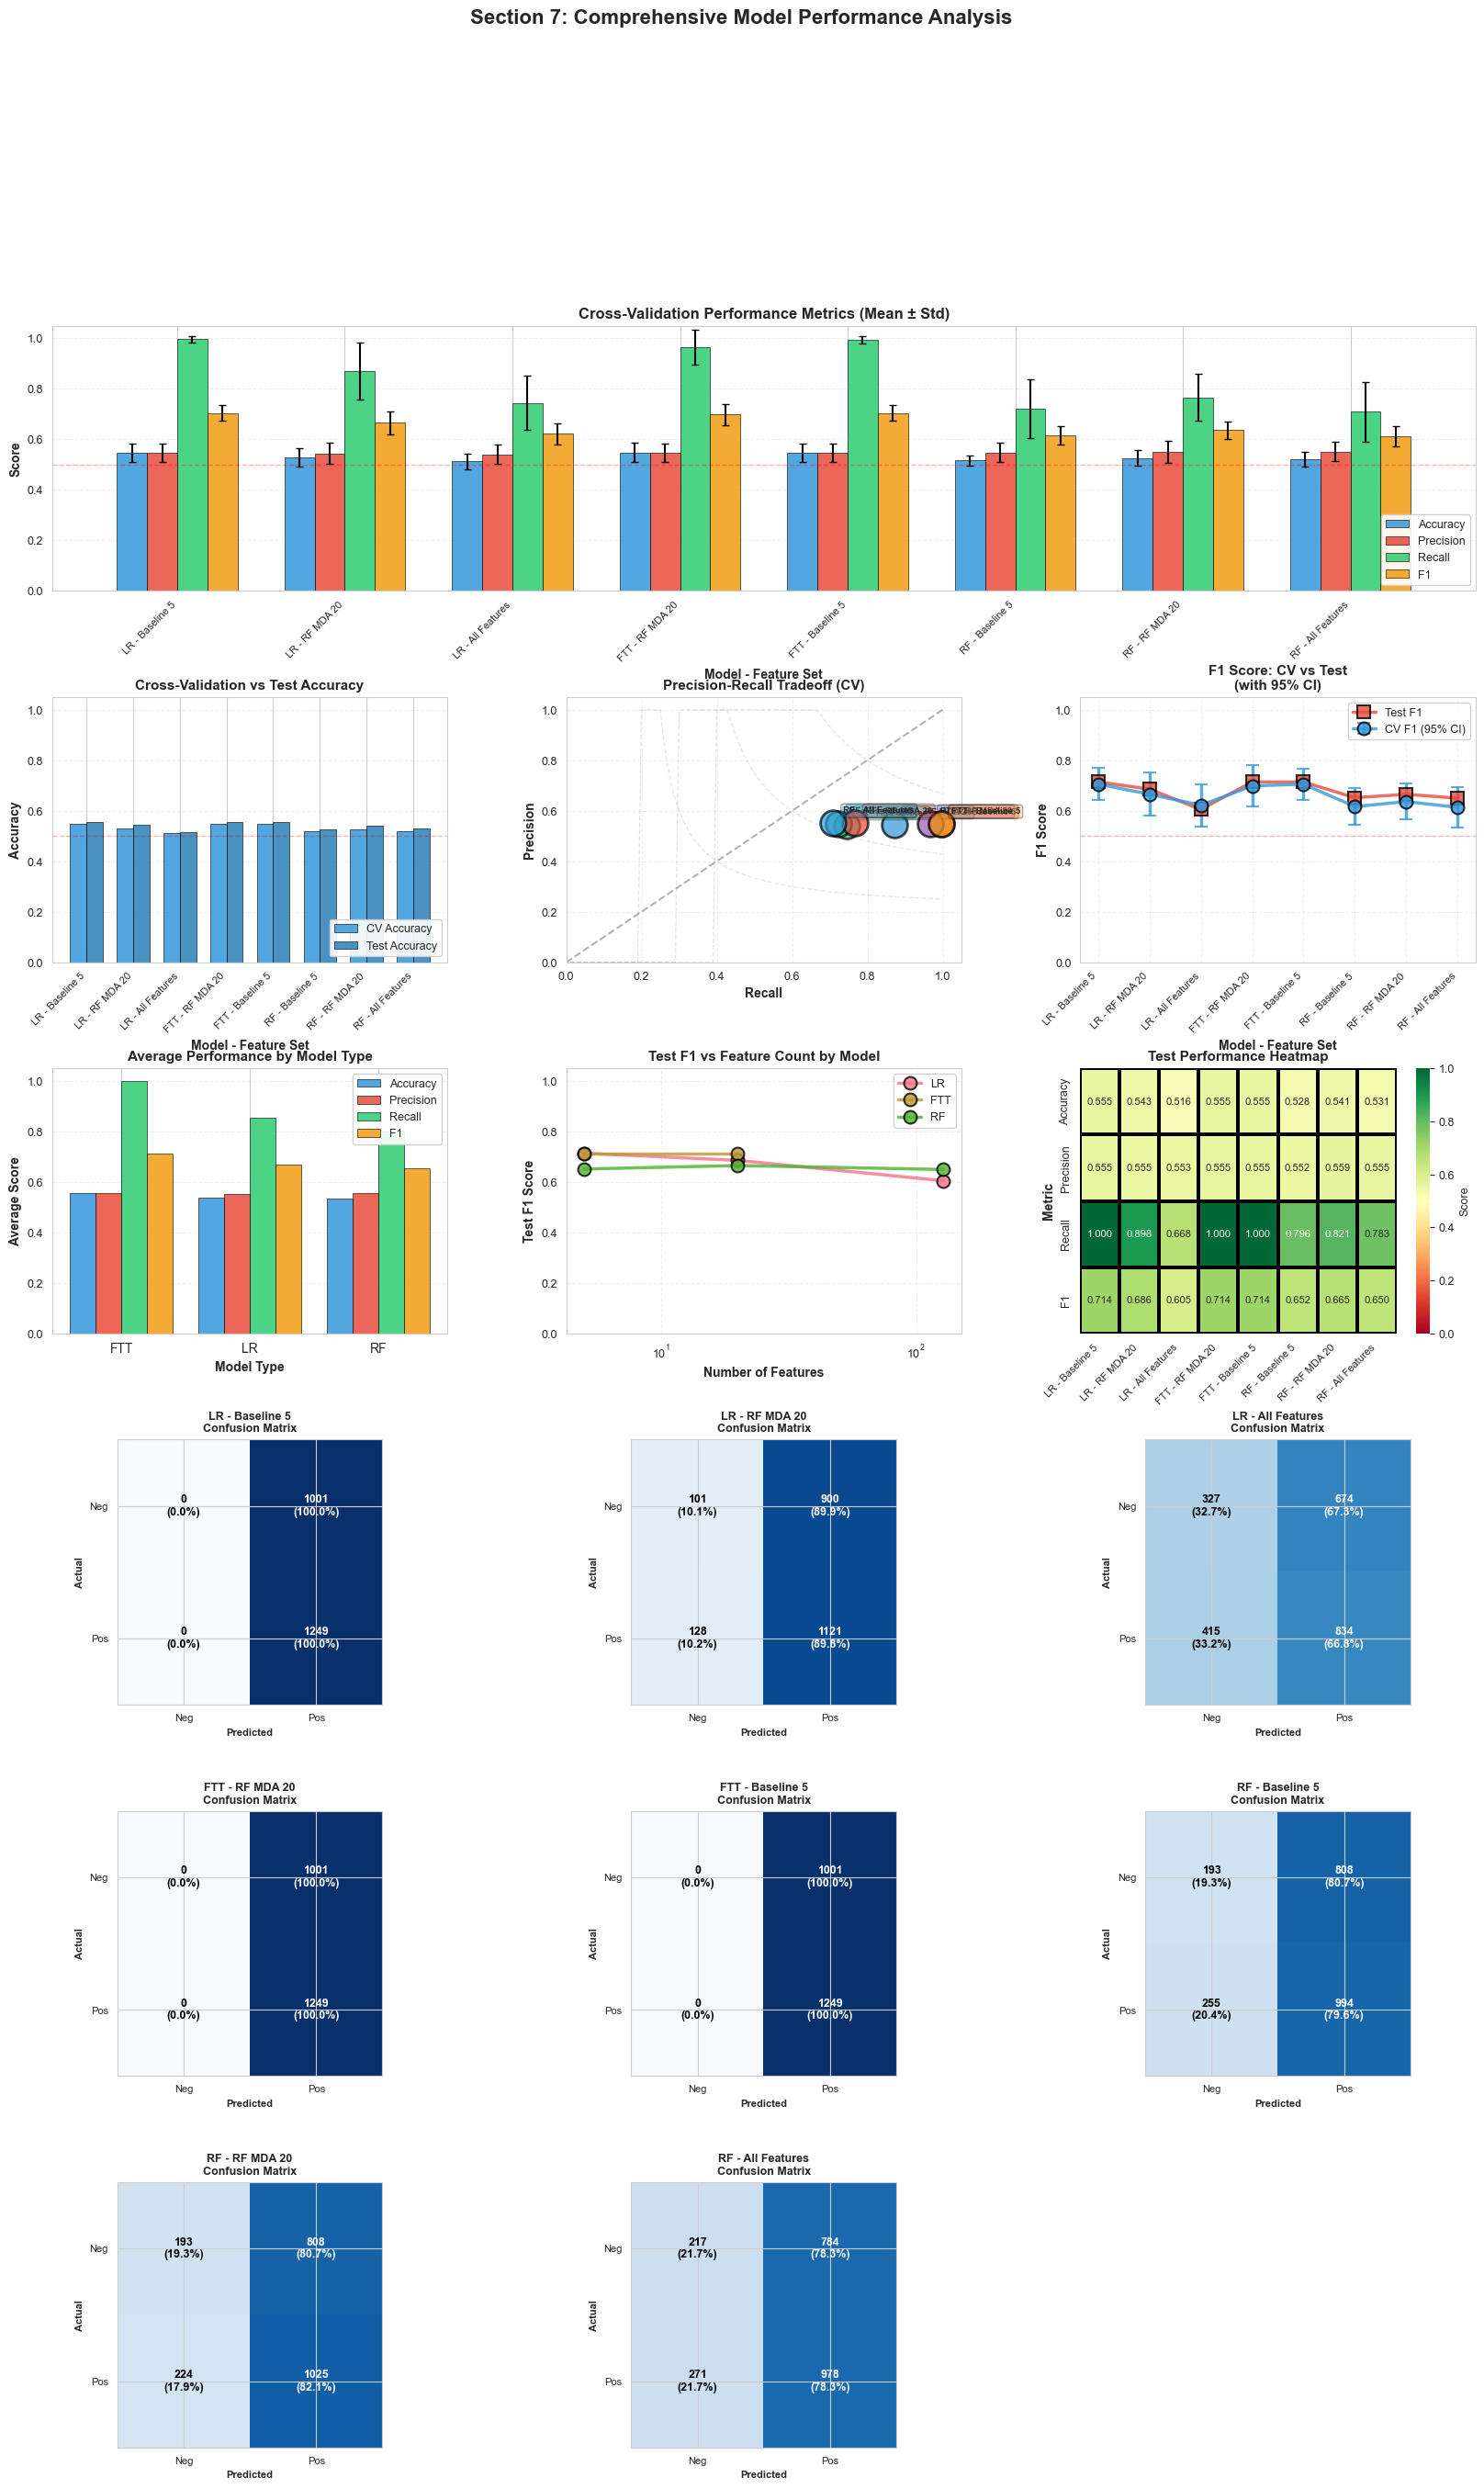


MODEL PERFORMANCE SUMMARY TABLE
Model  Feature Set  N Features CV Accuracy CV Precision CV Recall  CV F1 Test Accuracy Test Precision Test Recall Test F1
   LR   Baseline 5           5      0.5469       0.5465    0.9963 0.7052        0.5551         0.5551      1.0000  0.7139
   LR    RF MDA 20          20      0.5290       0.5447    0.8710 0.6655        0.5431         0.5547      0.8975  0.6856
   LR All Features         128      0.5127       0.5415    0.7452 0.6219        0.5160         0.5531      0.6677  0.6050
  FTT    RF MDA 20          20      0.5482       0.5479    0.9658 0.6982        0.5551         0.5551      1.0000  0.7139
  FTT   Baseline 5           5      0.5475       0.5472    0.9950 0.7053        0.5551         0.5551      1.0000  0.7139
   RF   Baseline 5           5      0.5176       0.5489    0.7227 0.6163        0.5276         0.5516      0.7958  0.6516
   RF    RF MDA 20          20      0.5268       0.5505    0.7665 0.6363        0.5413         0.5592      0.8207

In [83]:
df_results = create_comprehensive_visualization(all_results)

Save the final training result for future reference, no need to run again :)

In [85]:
import pickle

# Save all_results to a file for future reference
with open("final_all_results.pkl", "wb") as f:
    pickle.dump(all_results, f)


In [141]:
import pandas as pd

# Flatten all_results into rows for a dataframe and show ALL metrics, not just test_metrics
rows = []

def flatten_dict(d, parent_key=''):
    """Utility to flatten nested dicts with dot paths."""
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}.{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key).items())
        else:
            items.append((new_key, v))
    return dict(items)

for model, feats in all_results.items():
    for feature_set, result in feats.items():
        # Flatten everything, including nested test_metrics, fit_time, cv_metrics, etc.
        base_row = {
            "Model": model.upper(),
            "Feature Set": feature_set,
        }

        if isinstance(result, dict):
            flat_metrics = flatten_dict(result)
        else:
            flat_metrics = {}

        # Write all metrics at the top level, not just 'test_metrics'
        # For consistency, keep the keys human-readable
        row = base_row.copy()
        for metric_key, value in flat_metrics.items():
            # For nicer display, capitalize confusion_matrix
            if metric_key.endswith("confusion_matrix"):
                display_key = metric_key.replace("confusion_matrix", "Confusion Matrix")
            else:
                display_key = metric_key
            row[display_key] = value
        rows.append(row)

df_all_metrics = pd.DataFrame(rows)
df_all_metrics.to_csv("all_model_metrics.csv", index=False)


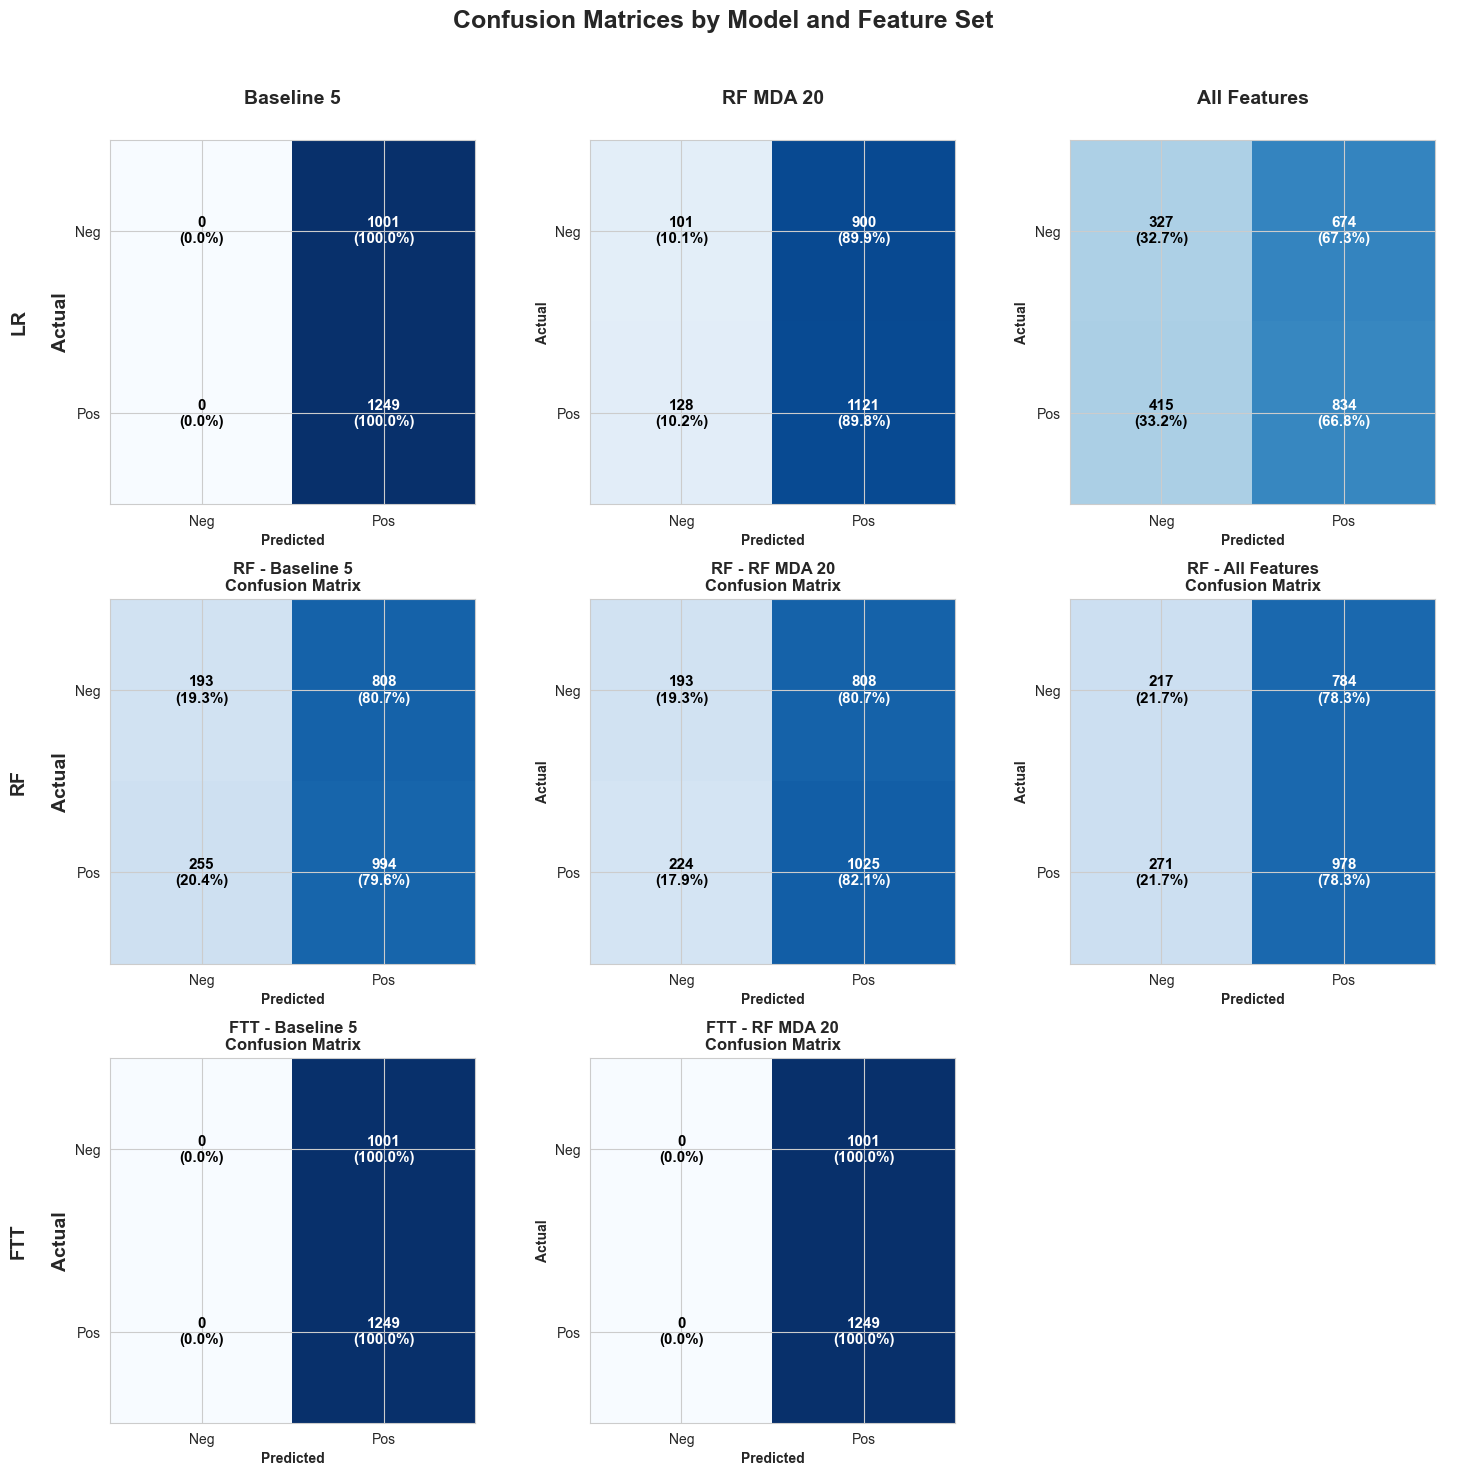

,Model,Feature Set,Confusion Matrix,Model_Feature
0,LR,Baseline 5,"[[0, 1001], [0, 1249]]",LR - Baseline 5
1,LR,RF MDA 20,"[[101, 900], [128, 1121]]",LR - RF MDA 20
2,LR,All Features,"[[327, 674], [415, 834]]",LR - All Features
3,RF,Baseline 5,"[[193, 808], [255, 994]]",RF - Baseline 5
4,RF,RF MDA 20,"[[193, 808], [224, 1025]]",RF - RF MDA 20
5,RF,All Features,"[[217, 784], [271, 978]]",RF - All Features
6,FTT,Baseline 5,"[[0, 1001], [0, 1249]]",FTT - Baseline 5
7,FTT,RF MDA 20,"[[0, 1001], [0, 1249]]",FTT - RF MDA 20


In [140]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def show_confusion_matrices_grid(all_results):
    """
    Displays confusion matrices in a fixed 3x3 grid:
    Rows: LR, RF, FTT
    Cols: Baseline 5, RF MDA 20, All Features
    """
    # Adjusted names for correct keys
    model_order = ['lr', 'rf', 'ftt']
    feature_order = ['Baseline_5', 'RF_MDA_20', 'All_Features']
    model_display = {'lr': 'LR', 'rf': 'RF', 'ftt': 'FTT'}
    feature_display = {
        'Baseline_5': 'Baseline 5',
        'RF_MDA_20': 'RF MDA 20',
        'All_Features': 'All Features'
    }

    # Extract confusion matrices into a (3, 3) structure
    n_rows = len(model_order)
    n_cols = len(feature_order)
    data_matrix = [[None for _ in range(n_cols)] for _ in range(n_rows)]

    for model_idx, model_type in enumerate(model_order):
        feature_sets = all_results.get(model_type, {})
        for feat_idx, feat_key in enumerate(feature_order):
            metrics = feature_sets.get(feat_key, None)
            if metrics is not None:
                # Support for possibly nested dicts (like with grid search results); get last confusion matrix if list
                # Defensive: check if 'test_metrics' exists and is a dict
                test_metrics = metrics.get('test_metrics', None)
                if isinstance(test_metrics, dict):
                    cm_val = test_metrics.get('confusion_matrix', None)
                else:
                    cm_val = None
                if isinstance(cm_val, list) and len(cm_val) > 0:
                    cm_val = cm_val[-1]
                # Only allow cm_val if it's array-like 2x2
                if isinstance(cm_val, (np.ndarray, list)) and np.array(cm_val).shape == (2, 2):
                    safe_cm_val = np.array(cm_val)
                else:
                    safe_cm_val = None
                data_matrix[model_idx][feat_idx] = {
                    'Model': model_display[model_type],
                    'Feature Set': feature_display[feat_key],
                    'Confusion Matrix': safe_cm_val
                }

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows), squeeze=False)

    for i in range(n_rows):
        for j in range(n_cols):
            ax = axes[i, j]
            cell = data_matrix[i][j]
            if cell is not None and cell['Confusion Matrix'] is not None:
                cm = np.array(cell['Confusion Matrix'])
                if cm.shape != (2,2):
                    ax.axis('off')
                    continue
                if cm.sum() == 0:  # Avoid divide by zero
                    cm_norm = np.zeros_like(cm, dtype=float)
                else:
                    denom = cm.sum(axis=1, keepdims=True)
                    denom[denom == 0] = 1  # Avoid division by zero for empty classes
                    cm_norm = cm.astype('float') / denom
                ax.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
                ax.set_title(f"{cell['Model']} - {cell['Feature Set']}\nConfusion Matrix",
                             fontweight='bold', fontsize=12)

                # Add counts and normalized values
                for m in range(cm.shape[0]):
                    for n in range(cm.shape[1]):
                        text = f"{cm[m, n]}\n({cm_norm[m, n]:.1%})" if cm.sum() > 0 else f"{cm[m, n]}"
                        ax.text(n, m, text, ha="center", va="center",
                                color="white" if cm_norm[m, n] > 0.5 else "black",
                                fontsize=11, fontweight='bold')
                ax.set_xticks([0,1])
                ax.set_yticks([0,1])
                ax.set_xticklabels(['Neg', 'Pos'], fontsize=10)
                ax.set_yticklabels(['Neg', 'Pos'], fontsize=10)
                ax.set_xlabel('Predicted', fontweight='bold', fontsize=10)
                ax.set_ylabel('Actual', fontweight='bold', fontsize=10)
            else:
                ax.axis('off')

    # Set big column headers (make sure axes[0, col_idx] exists)
    for col_idx, feat in enumerate(feature_order):
        axes[0, col_idx].set_title(feature_display[feat], fontweight='bold', fontsize=14, pad=26)
    # Set big row headers (make sure axes[row_idx, 0] exists)
    for row_idx, model in enumerate(model_order):
        y_lab = model_display[model] + "\n\nActual"
        axes[row_idx, 0].set_ylabel(y_lab, fontweight='bold', fontsize=14)

    fig.suptitle('Confusion Matrices by Model and Feature Set', fontsize=18, fontweight='bold')
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    # Return a useful DataFrame for inspection
    flat_data = []
    for i, model in enumerate(model_order):
        for j, feat in enumerate(feature_order):
            entry = data_matrix[i][j]
            if entry is not None and entry['Confusion Matrix'] is not None:
                flat_data.append({
                    'Model': entry['Model'],
                    'Feature Set': entry['Feature Set'],
                    'Confusion Matrix': entry['Confusion Matrix'],
                    'Model_Feature': entry['Model'] + ' - ' + entry['Feature Set']
                })
    df = pd.DataFrame(flat_data)
    return df

show_confusion_matrices_grid(all_results)